In [2]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from landaupy import langauss
import pandas as pd
from scipy.odr import Model, RealData, ODR
from scipy.optimize import minimize
import numdifftools as nd
from matplotlib.gridspec import GridSpec
from iminuit import Minuit  # iminuit‑Kern
import warnings
%matplotlib widget

In [4]:
### functions
def read_data(file, cutoff=0):
    '''
    reads data from file specifically from TKA file
    args:
        file (str): path to file
        cutoff (int) (default: 0): number of lines to skip 
    returns:
        data (array): data
    '''
    l = []
    with open(file) as data:
        for line in data:
            l.append(int(line))
    return np.array(l[cutoff:])


def load_rigol_two_channel(file):
    '''
    reads data from file specifically from Rigol oscilloscope two path file
    args:
        file (str): path to file
    returns:
        t (array): time values
        ch1 (array): channel 1 values
        ch2 (array): channel 2 values
    '''

    # Header lesen
    with open(file) as f:
        lines = f.readlines()

    header = lines[1].split(",")

    t_start = float(header[3])
    dt = float(header[4])

    # Daten laden
    df = pd.read_csv(
        file,
        skiprows=2,
        usecols=[0,1,2],
        names=["i","ch1","ch2"]
    )

    i = df["i"].values
    ch1 = df["ch1"].values
    ch2 = df["ch2"].values

    t = t_start + i * dt

    return t, ch1, ch2

def threshold_time(t, signal, fraction=0.5):
    ''' 
    calculates the threshold time for a given signal accoring to a given fraction
    args:
        t (array): time values
        signal (array): signal values
        fraction (float): threshold fraction
    returns:
        t_thr (float): threshold time
    '''

    A = np.min(signal)
    thr = fraction * A

    idx = np.where(signal < thr)[0][0]

    # lineare Interpolation
    t1, t2 = t[idx-1], t[idx]
    y1, y2 = signal[idx-1], signal[idx]

    return t1 + (thr-y1)*(t2-t1)/(y2-y1)

def bin_data_poisson(x, y, yerr, bin_width):
    ''' 
    bins data for poisson errors
    args:
        x (array): x-values
        y (array): y-values
        yerr (array): y-errors
        bin_width (int): bin width
    returns:
        x_binned (array): binned x-values
        y_binned (array): binned y-values
        error_binned (array): binned y-errors
    '''
    n_bins = len(x) // bin_width

    x_binned = []
    y_binned = []
    error_binned = []

    for i in range(n_bins):
        start = i * bin_width
        end = start + bin_width

        x_bin = x[start:end]
        y_bin = y[start:end]
        err_bin = yerr[start:end]

        x_binned.append(np.mean(x_bin))
        y_binned.append(np.sum(y_bin))
        error_binned.append(np.sqrt(np.sum(err_bin**2)))

    return np.array(x_binned), np.array(y_binned), np.array(error_binned)

def uncertainty_rate(N, t, dt):
    ''' 
    calculates uncertainty of the rate

    args:
        N (array): number of counts
        t (array): time
        dt (float): time step
    returns:
        returns sqrt(1/t**2 + 1**2/t**4 * dt**2)

    '''
    N = np.asarray(N, dtype=float)
    #term = np.where(N>0, N/t**2 + N**2/t**4 * dt**2, 1/t**2 + 1**2/t**4 * dt**2)
    return np.sqrt(N/t**2 + N**2/t**4 * dt**2)

def gauss(x, A, mu, sigma):
    '''  
    Gaussian function
    args:
        x (array): x-values
        A (float): amplitude
        mu (float): mean
        sigma (float): standard deviation
    returns:
        y (array): y-values
    '''
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

def exp_decay_with_offset(x, A, tau, C):
    '''
    Exponential decay function with offset
    args:
        x (array): x-values
        A (float): amplitude
        tau (float): decay constant
        C (float): offset
    returns:
        y (array): y-values
    '''
    return A * np.exp(-x / tau) + C

def linear(x, m, b):
    '''
    Linear function
    args:
        x (array): x-values
        m (float): slope
        b (float): intercept
    returns:
        y (array): y-values
    '''
    return m * x + b

# lineare Funktion
def linear_func(B, x):
    ''' 
    lineare function for odr fit
    args:
        B (array): parameters in order of [m, b]
        x (array): x-values
    returns:
        y (array): y-values
    '''
    return B[0] * x + B[1]  # B[0] = m, B[1] = b

### functions
def fit_langauss(x, mpv, xi, sigma, scale):
    """
    Landau_Gauss fitting function
    Args:
        x (array): x-values
        mpv (float): most probable value of the Landau distribution
        xi (float): width of the Landau distribution
        sigma (float): width of the Gaussian distribution
        scale (float): scaling factor
    returns:
        y (array): y-values
    """

    return scale * langauss.pdf(x, mpv, xi, sigma)


# Negative Log-Likelihood der Poissonverteilung
def nll(theta, x, k, model):
    '''  
    Negative log-likelihoof for poisson distributed data

    args:
        theta (array): parameters in order of [A, mu, sigma]
        x (array): x-values
        k (array): y-values
        model (string): model name
    returns:
        y (array): y-values
    '''
    lam = model(x, *theta)
    return np.sum(lam - k * np.log(lam))


def fit_with_iminuit(x, y, model, p0, bounds=None, verbose=False, asymmetric=False):
    """
    Minimiert die Poisson‑NLL mit iminuit und gibt Parameter + Fehler zurück.
    Parameters
    ----------
    x, y      : 1‑D arrays (x‑Werte, gemessene Rate)
    model     : callable, model(x, *params) → erwartete Rate
    p0        : list/array mit Anfangswerten
    bounds    : [(low0,high0), (low1,high1), …]  (oder None)
    verbose   : bool, ob Minuit‑Ausgabe im Terminal erwünscht ist
    asymmetric: bool, wenn True: Minos Fehler

    Returns
    -------
    popt      : ndarray  – beste Parameterschätzung
    perr      : ndarray  – symmetrische 1‑σ‑Fehler (aus Hesse)
    perr_low  : ndarray  – untere MINOS‑Fehler (nur wenn asymmetric=True)
    perr_up   : ndarray  – obere MINOS‑Fehler (nur wenn asymmetric=True)
    minuit    : iminuit.Minuit‑Objekt (enthält z. B. Korrelationsmatrix)
    """
    # ---- 1. Funktion, die iminuit minimieren soll -----------------
    def _nll(*theta):
        return nll(theta, x, y, model)

    # Minuit‑Instanz erzeugen
    minuit = Minuit(_nll, *p0)          # *p0 = Anfangswerte für jedes Parameter
    minuit.errordef = Minuit.LIKELIHOOD
    # (optional) Parameter‑Grenzen setzen
    minuit.limits = bounds               # z. B. [(0, None), (0, None), (0, None)]

    # Minimierung → entspricht früher `migrad(minuit, ...)`
    minuit.migrad()                     # oder minuit.migrad(verbose=True)

    # Prüfen, ob der Fit konvergiert ist
    if not minuit.fmin.is_valid:
        import warnings
        warnings.warn("iminuit minimisation not converged!")

    # Fehler bestimmen → entspricht früher `hesse(minuit, ...)`
    minuit.hesse()                      # liefert symmetrische 1‑σ‑Fehler
    # Für asymmetrische Fehler (empfohlen bei stark schiefer Likelihood):
    # minuit.minos()   # etwas langsamer, liefert low/up‑Fehler

    # Ergebnisse auslesen
    popt = np.array(minuit.values)      # beste Parameterschätzung
    perr = np.array(minuit.errors)      # symmetrische Fehler (Hesse)
    # falls du MINOS benutzt:
    if asymmetric:
        # MINOS kann ein paar Sekunden dauern – das ist normal.
        minos_result = minuit.minos()

    #     # ---- 7a. Neue API (iminuit ≥ 2.0) -----------------------
    #     if hasattr(minuit, "errors_low") and hasattr(minuit, "errors_up"):
    #         # `errors_low` / `errors_up` sind Dictionaries.
    #         perr_low = np.array([minuit.errors_low[p] for p in minuit.parameters])
    #         perr_up  = np.array([minuit.errors_up[p]  for p in minuit.parameters])
    #     # ---- 7b. Alte API (iminuit ≤ 1.x) -----------------------
    #     else:
    #         # `minos_result` ist ein Dict: {'p0': (low, up), …}
    #         perr_low = np.array([minos_result[p][0] for p in minuit.parameters])
    #         perr_up  = np.array([minos_result[p][1] for p in minuit.parameters])
    # else:
    #     perr_low = perr_up = None    # symmetrische 1‑σ‑Fehler

    return popt, perr, minuit


## General Values

In [5]:
dt_spectrometer = 0.3 # s

## Photo Electron Statistics

hier ganz normal curve_fit, weil statistik groß genug

(890, 1300)
(1200, 2000)
(1550, 2500)
(2000, 2600)


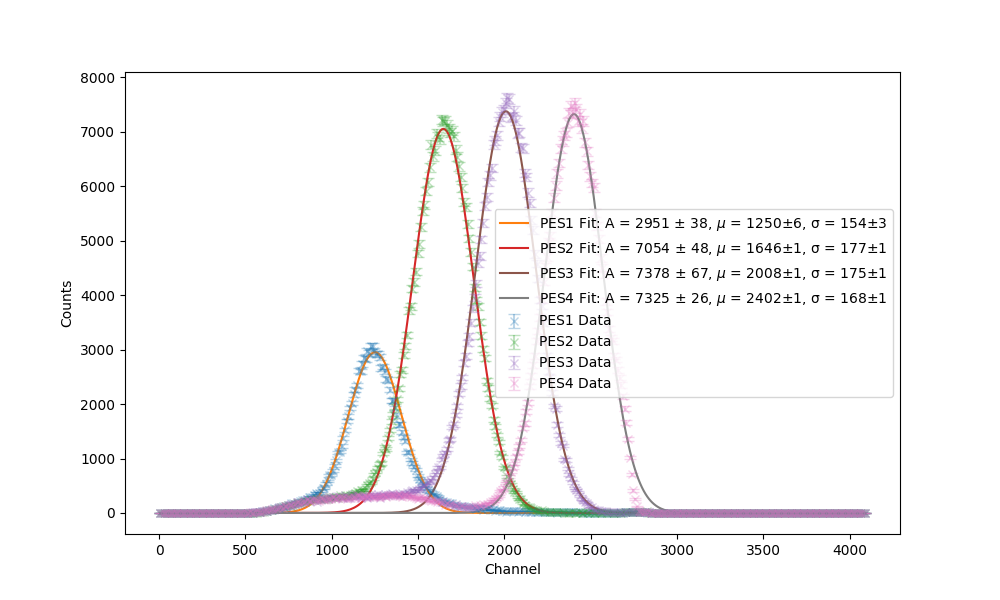

In [121]:
# PES1 = read_data('RawData/spectrum/PES_1.TKA', cutoff = 2)
# PES1_channels = np.arange(2, 2 + len(PES1))

# PES1_uncertainty = np.sqrt(PES1)

# # bin data
# PES1_channels, PES1, PES1_err = bin_data_poisson(PES1_channels, PES1, PES1_uncertainty, 10)

# # mask fitting range
# mask_PES1 = (PES1_channels > 890) & (PES1_channels < 1300) & (PES1 > 0)

# # fit gaussian
# popt_PES1, pcov_PES1 = curve_fit(gauss, PES1_channels[mask_PES1], PES1[mask_PES1], sigma = PES1_err[mask_PES1], p0 = [np.max(PES1), PES1_channels[np.argmax(PES1)], 150])

# plt.figure()
# plt.errorbar(PES1_channels, PES1, yerr = PES1_err, fmt='x', capsize=4, label='Data', alpha = 0.3)
# plt.plot(PES1_channels, gauss(PES1_channels, *popt_PES1), 'r-', label = f'Fit: mu = {popt_PES1[1]:.0f} $\pm$ {np.sqrt(pcov_PES1[1,1]):.0f}, sigma = {popt_PES1[2]:.0f} $\pm$ {np.sqrt(pcov_PES1[2,2]):.0f}')
# plt.legend()
# plt.xlabel('Channel')
# plt.ylabel('Counts')


files = [
         'RawData/spectrum/PES_1.TKA',
         'RawData/spectrum/PES_2.TKA',
         'RawData/spectrum/PES_3.TKA',
         'RawData/spectrum/PES_4.TKA']
        #  'RawData/spectrum/PES_5.TKA',
        #  'RawData/spectrum/PES_6.TKA']
        #  'RawData/spectrum/PES_7.TKA',
        #  'RawData/spectrum/PES_8.TKA',
        #  'RawData/spectrum/PES_9.TKA',
        #  'RawData/spectrum/PES_10.TKA']

# Masken für jede Datei individuell (Channel-Bereiche)
fit_masks = [
    (890, 1300),  # PES1
    (1200, 2000),  # PES2
    (1550, 2500),  # PES3
    (2000, 2600),   # PES4
    # (550, 1050),   # PES5
    # (800, 1500),   # PES6
    # (600, 1100),   # PES7
    # (1000, 1500),   # PES8
    # (1550, 2200),   # PES9
    # (2250, 2750),   # PES10
]

bin_width = 10

sigma_PES = []
dsigma_PES = []

plt.figure(figsize=(10, 6))

for i, (file, mask_range) in enumerate(zip(files, fit_masks), 1):
    # Daten einlesen
    PES = read_data(file, cutoff=2)
    PES_channels = np.arange(2, 2 + len(PES))
    PES_uncertainty = np.sqrt(PES)
    
    # Daten binned
    PES_channels_b, PES_b, PES_err_b = bin_data_poisson(PES_channels, PES, PES_uncertainty, bin_width)
    
    # Fitting-Maske individuell
    print(mask_range)
    mask = (PES_channels_b > mask_range[0]) & (PES_channels_b < mask_range[1]) & (PES_b > 0)
    
    # Initial guess: Amplitude, Mittelwert, Sigma
    masked_channels = PES_channels_b[mask]
    masked_counts = PES_b[mask]

    max_index = np.argmax(masked_counts)
    mu_guess = masked_channels[max_index]

    p0 = [masked_counts[max_index], mu_guess, 150]
    
    # Gaussian Fit
    popt, pcov = curve_fit(gauss, PES_channels_b[mask], PES_b[mask], sigma=PES_err_b[mask], p0=p0)
    
    sigma_PES.append(popt[2])
    dsigma_PES.append(np.sqrt(pcov[2,2]))
    # Plot Daten + Fit
    plt.errorbar(PES_channels_b, PES_b, yerr=PES_err_b, fmt='x', capsize=4, alpha=0.3, label=f'PES{i} Data')
    plt.plot(PES_channels_b, gauss(PES_channels_b, *popt), '-', label=f'PES{i} Fit: A = {popt[0]:.0f} $\pm$ {np.sqrt(pcov[0,0]):.0f}, $\mu$ = {popt[1]:.0f}$\pm${np.sqrt(pcov[1,1]):.0f}, σ = {popt[2]:.0f}$\pm${np.sqrt(pcov[2,2]):.0f}')

plt.xlabel('Channel')
plt.ylabel('Counts')
plt.legend()
plt.savefig('Results/PES_constant_duty.pdf')
plt.show()


In [268]:
# Gewichteter Mittelwert
sigma_PES = np.array([sigma_PES])
dsigma_PES = np.array([dsigma_PES])
weights = 1.0 / dsigma_PES**2
sigma_PES_single_value = np.average(sigma_PES, weights=weights)

# Fehler auf den gewichteten Mittelwert
dsigma_PES_single_value = np.sqrt(1.0 / np.sum(weights))

print(f"Weighted mean = {sigma_PES_single_value} ± {dsigma_PES_single_value}")
print(dsigma_PES)

Weighted mean = 171.51932124627072 ± 0.469311960209559
[[3.45203392 0.89813683 1.02783943 0.66371698]]


#### varying duty

(600, 1100)
(1000, 1500)
(1550, 2200)
(2250, 2750)


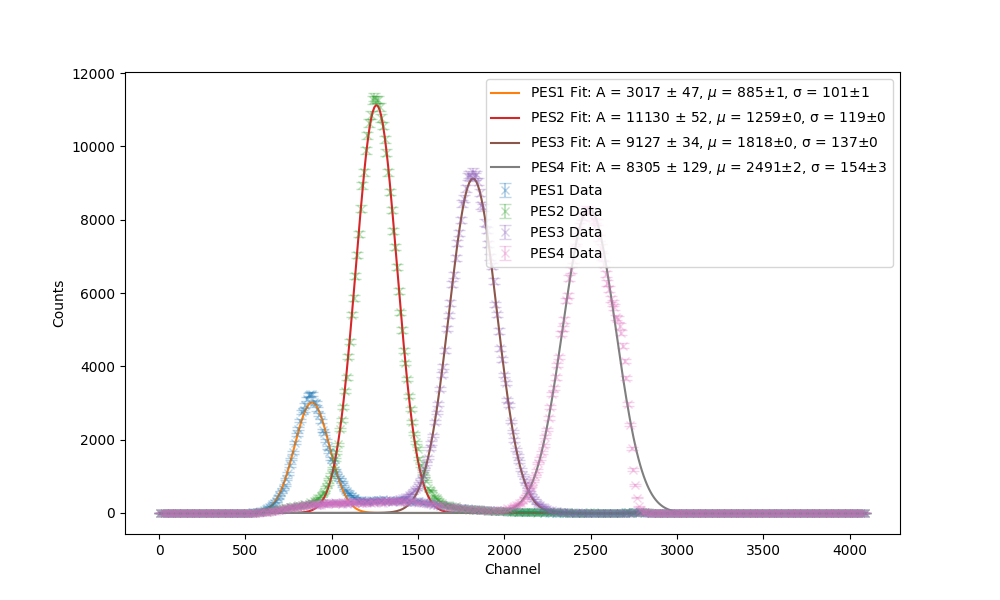

In [122]:
files = [

         'RawData/spectrum/PES_7.TKA',
         'RawData/spectrum/PES_8.TKA',
         'RawData/spectrum/PES_9.TKA',
         'RawData/spectrum/PES_10.TKA']

# Masken für jede Datei individuell (Channel-Bereiche)
fit_masks = [
    (600, 1100),   # PES7
    (1000, 1500),   # PES8
    (1550, 2200),   # PES9
    (2250, 2750),   # PES10
]

bin_width = 10

sigma_PES_duty = []
dsigma_PES_duty = []
mu_PES_duty = []
dmu_PES_duty = []

plt.figure(figsize=(10, 6))

for i, (file, mask_range) in enumerate(zip(files, fit_masks), 1):
    # Daten einlesen
    PES = read_data(file, cutoff=2)
    PES_channels = np.arange(2, 2 + len(PES))
    PES_uncertainty = np.sqrt(PES)
    
    # Daten binned
    PES_channels_b, PES_b, PES_err_b = bin_data_poisson(PES_channels, PES, PES_uncertainty, bin_width)
    
    # Fitting-Maske individuell
    print(mask_range)
    mask = (PES_channels_b > mask_range[0]) & (PES_channels_b < mask_range[1]) & (PES_b > 0)
    
    # Initial guess: Amplitude, Mittelwert, Sigma
    masked_channels = PES_channels_b[mask]
    masked_counts = PES_b[mask]

    max_index = np.argmax(masked_counts)
    mu_guess = masked_channels[max_index]

    p0 = [masked_counts[max_index], mu_guess, 150]
    
    # Gaussian Fit
    popt, pcov = curve_fit(gauss, PES_channels_b[mask], PES_b[mask], sigma=PES_err_b[mask], p0=p0)
    
    sigma_PES_duty.append(popt[2])
    dsigma_PES_duty.append(np.sqrt(pcov[2,2]))
    mu_PES_duty.append(popt[1])
    dmu_PES_duty.append(np.sqrt(pcov[1,1]))
    # Plot Daten + Fit
    plt.errorbar(PES_channels_b, PES_b, yerr=PES_err_b, fmt='x', capsize=4, alpha=0.3, label=f'PES{i} Data')
    plt.plot(PES_channels_b, gauss(PES_channels_b, *popt), '-', label=f'PES{i} Fit: A = {popt[0]:.0f} $\pm$ {np.sqrt(pcov[0,0]):.0f}, $\mu$ = {popt[1]:.0f}$\pm${np.sqrt(pcov[1,1]):.0f}, σ = {popt[2]:.0f}$\pm${np.sqrt(pcov[2,2]):.0f}')

plt.xlabel('Channel')
plt.ylabel('Counts')
plt.legend()
plt.savefig('Results/PES_varying_duty.pdf')
plt.show()


ODR fit (duty): m = 0.0349 ± 0.0028, b = 73.8355 ± 4.4802


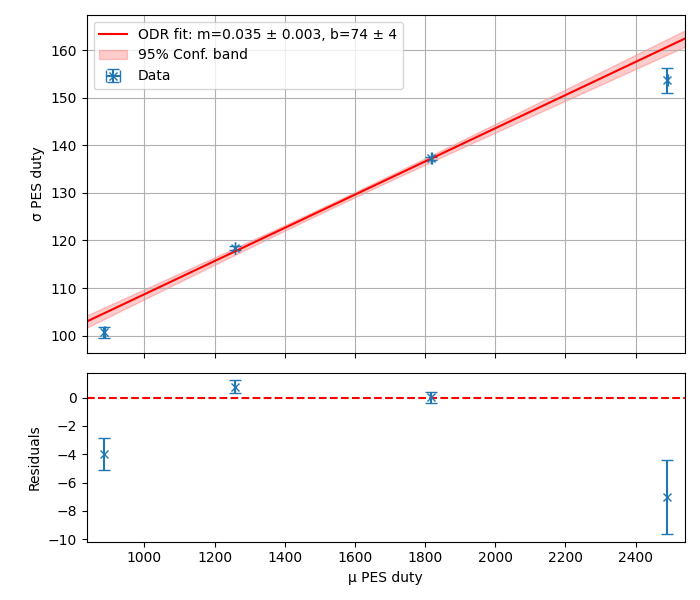

In [130]:
# --- Daten in NumPy-Arrays umwandeln ---
mu_PES_duty = np.array(mu_PES_duty)
sigma_PES_duty = np.array(sigma_PES_duty)
dmu_PES_duty = np.array(dmu_PES_duty)
dsigma_PES_duty = np.array(dsigma_PES_duty)

# --- Lineares Modell ---
def linear_func(beta, x):
    return beta[0]*x + beta[1]  # y = m*x + b

# --- Datenobjekt mit Unsicherheiten ---
data_duty = RealData(mu_PES_duty, sigma_PES_duty, sx=dmu_PES_duty, sy=dsigma_PES_duty)

# --- Modell ---
model_duty = Model(linear_func)

# --- Initial guesses ---
beta0_duty = [1.0, 0.0]

# --- ODR durchführen ---
odr_duty = ODR(data_duty, model_duty, beta0=beta0_duty)
out_duty = odr_duty.run()

# --- Fitparameter + Fehler ---
m_duty, b_duty = out_duty.beta
dm_duty, db_duty = out_duty.sd_beta
print(f"ODR fit (duty): m = {m_duty:.4f} ± {dm_duty:.4f}, b = {b_duty:.4f} ± {db_duty:.4f}")

# --- Fitkurve ---
x_fit_duty = np.linspace(min(mu_PES_duty)-50, max(mu_PES_duty)+50, 500)
y_fit_duty = linear_func([m_duty, b_duty], x_fit_duty)

# --- Kovarianzmatrix für Konfidenzband ---
cov_duty = out_duty.cov_beta
var_m_duty = cov_duty[0,0]
var_b_duty = cov_duty[1,1]
cov_mb_duty = cov_duty[0,1]
sigma_y_duty = np.sqrt(var_b_duty + x_fit_duty**2*var_m_duty + 2*x_fit_duty*cov_mb_duty)

# 95% Konfidenzband
t = 1.96
y_upper_duty = y_fit_duty + t*sigma_y_duty
y_lower_duty = y_fit_duty - t*sigma_y_duty

# --- Residuen ---
residues_duty = sigma_PES_duty - (m_duty*mu_PES_duty + b_duty)

# --- Plot mit zwei Subplots ---
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(7,6), sharex=True,
                               gridspec_kw={'height_ratios':[2,1]})

# Obere Achse: Fit mit Konfidenzband
ax0.errorbar(mu_PES_duty, sigma_PES_duty, xerr=dmu_PES_duty, yerr=dsigma_PES_duty,
             fmt='x', capsize=4, label='Data')
ax0.plot(x_fit_duty, y_fit_duty, 'r', label=f'ODR fit: m={m_duty:.3f} ± {dm_duty:.3f}, b={b_duty:.0f} ± {db_duty:.0f}')
ax0.fill_between(x_fit_duty, y_lower_duty, y_upper_duty, color='red', alpha=0.2, label='95% Conf. band')
ax0.set_ylabel("σ PES duty")
ax0.grid(True)
ax0.legend()

# Untere Achse: Residuen
ax1.errorbar(mu_PES_duty, residues_duty, yerr=dsigma_PES_duty,
             fmt='x', capsize=4)
ax1.axhline(0, color='red', linestyle='--')
ax1.set_xlabel("μ PES duty")
ax1.set_ylabel("Residuals")
plt.xlim(min(x_fit_duty), max(x_fit_duty))

plt.savefig('Results/PES_sigma_vs_mu.pdf')
plt.tight_layout()
plt.show()

## Pedestal Measurement
hier poisson statistik mit iminuit

A = 134.8 ± 1.0
μ = 410.0 ± 0.5
σ = 82.1 ± 0.4


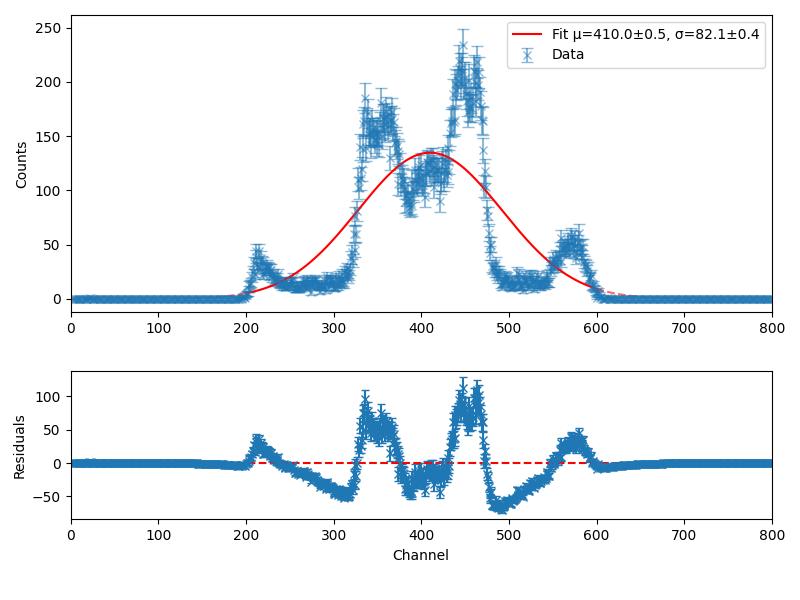

In [115]:
pedestal_1_100 = read_data('RawData/spectrum/pedestal_1.TKA', cutoff=2)
pedestal_1_channel_100 = np.arange(2, 2 + len(pedestal_1_100))

# --- Zusätzliche Maske: nur Werte > 0 für Fit verwenden ---
valid_mask_100 = pedestal_1_100 > 0

# --- Fitbereich auswählen ---
mask_100 = (pedestal_1_channel_100 > 200) & (pedestal_1_channel_100 < 600) & valid_mask_100

pedestal_1_masked_100 = pedestal_1_100[mask_100]
pedestal_1_channel_masked_100 = pedestal_1_channel_100[mask_100]

# Startwerte für Fit
p0_100 = [
    np.max(pedestal_1_masked_100),                                  # A
    pedestal_1_channel_masked_100[np.argmax(pedestal_1_masked_100)], # mu
    10                                                               # sigma
]

# --- Fit mit iminuit ---
popt_100, perr_100, minuit_100 = fit_with_iminuit(
    pedestal_1_channel_masked_100,
    pedestal_1_masked_100,
    model=gauss,
    p0=p0_100,
    bounds=[(0, None), (None, None), (1e-6, None)]
)

A_hat_100, mu_hat_100, sigma_hat_100 = popt_100
A_err_100, mu_err_100, sigma_err_100 = perr_100

print(f"A = {A_hat_100:.1f} ± {A_err_100:.1f}")
print(f"μ = {mu_hat_100:.1f} ± {mu_err_100:.1f}")
print(f"σ = {sigma_hat_100:.1f} ± {sigma_err_100:.1f}")

# --- Modell über gesamten Bereich ---
lam_fit_100 = gauss(pedestal_1_channel_100, A_hat_100, mu_hat_100, sigma_hat_100)

# --- Residuen ---
residues_100 = pedestal_1_100 - lam_fit_100

# Fehler: NaN, wenn Wert <=0
resid_errors_100 = np.where(pedestal_1_100 > 0, np.sqrt(pedestal_1_100), np.nan)

# --- Plotmasken ---
x_min_100 = pedestal_1_channel_masked_100[0]
x_max_100 = pedestal_1_channel_masked_100[-1]

mask_left_100  = pedestal_1_channel_100 < x_min_100
mask_mid_100   = (pedestal_1_channel_100 >= x_min_100) & (pedestal_1_channel_100 <= x_max_100)
mask_right_100 = pedestal_1_channel_100 > x_max_100

# ---------------------------
# Plot
# ---------------------------
fig_100 = plt.figure(figsize=(8,6))
gs_100 = GridSpec(3, 1, height_ratios=[2, 1, 0.05])

ax0_100 = fig_100.add_subplot(gs_100[0])
ax1_100 = fig_100.add_subplot(gs_100[1], sharex=ax0_100)

# --- Daten ---
ax0_100.errorbar(
    pedestal_1_channel_100,
    pedestal_1_100,
    yerr=resid_errors_100,
    fmt='x',
    capsize=4,
    alpha=0.5,
    label='Data'
)

# --- Fit: außerhalb links ---
ax0_100.plot(
    pedestal_1_channel_100[mask_left_100],
    lam_fit_100[mask_left_100],
    color='red',
    linestyle='--',
    alpha=0.6
)

# --- Fitbereich: durchgezogen ---
ax0_100.plot(
    pedestal_1_channel_100[mask_mid_100],
    lam_fit_100[mask_mid_100],
    color='red',
    linestyle='-',
    label=f'Fit μ={mu_hat_100:.1f}±{mu_err_100:.1f}, σ={sigma_hat_100:.1f}±{sigma_err_100:.1f}'
)

# --- Fit: außerhalb rechts ---
ax0_100.plot(
    pedestal_1_channel_100[mask_right_100],
    lam_fit_100[mask_right_100],
    color='red',
    linestyle='--',
    alpha=0.6
)

# --- Residuen ---
ax1_100.errorbar(
    pedestal_1_channel_100,
    residues_100,
    yerr=resid_errors_100,
    fmt='x',
    capsize=3
)
ax1_100.axhline(0, color='red', linestyle='--')

ax1_100.set_xlabel('Channel')
ax1_100.set_ylabel('Residuals')
ax1_100.set_xlim(0, 800)

ax0_100.set_ylabel('Counts')
ax0_100.legend()
plt.tight_layout()
plt.savefig('Results/Pedestal.pdf')

In [116]:
pedestal_100 = mu_hat_100
dpedestal_100 = mu_err_100 
pedestal_50 = pedestal_100 * 0.5
dpedestal_50 = dpedestal_100 * 0.5
pedestal_25 = pedestal_100 * 0.25
dpedestal_25 = dpedestal_100 * 0.25
pedestal_63 = pedestal_100 * 0.63
dpedestal_63 = dpedestal_100 * 0.63



## Fly-Through-Spectrum

Best-fit-Parameter (symmetrisch):
MPV = 1430.791 ± 2.195
  ξ = 35.959 ± 1.224
  σ = 153.943 ± 1.954
  A = 194259.449 ± 1444.601


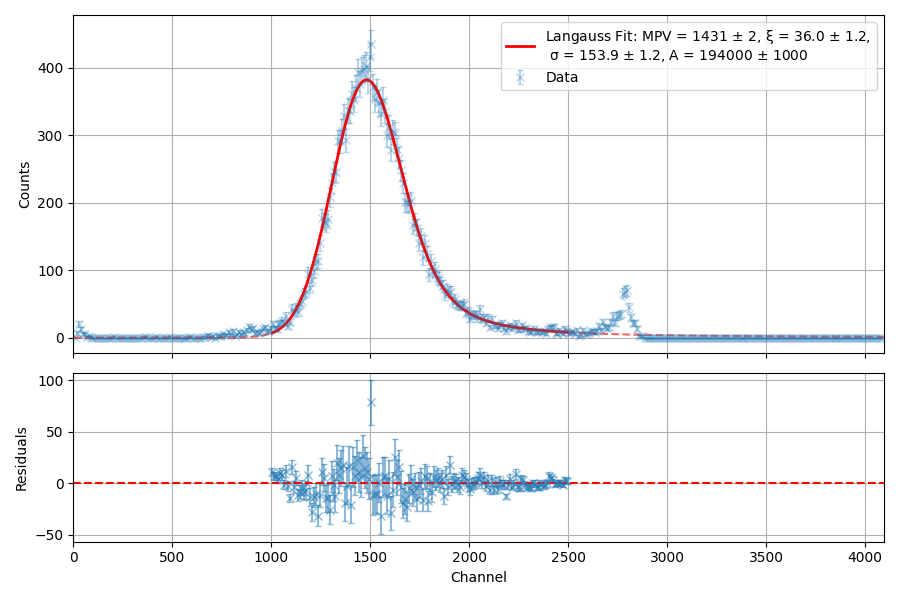

In [70]:
# -------------------------------
# Fit eines Flythrough-Spektrums mit Langauss-Funktion und Residuen
# -------------------------------

# --- Daten einlesen ---
data_100 = read_data('RawData/spectrum/flythrough_1.TKA', cutoff=2)
time_100 = read_data('RawData/spectrum/flythrough_1.TKA', cutoff=0)[0]
channels_100 = np.arange(2, 2 + len(data_100))

# --- Fehler (Poisson) ---
rate_100 = data_100
d_rate_100 = np.sqrt(data_100)

# --- Fitbereich auswählen ---
fit_mask_100 = (channels_100 >= 1000) & (channels_100 <= 2500)
x_fit_100 = channels_100[fit_mask_100]
y_fit_100 = rate_100[fit_mask_100]
dy_fit_100 = d_rate_100[fit_mask_100]

# --- Binning (für stabileren Fit) ---
bin_width_100 = 10
x_binned_100, y_binned_100, y_err_100 = bin_data_poisson(
    x_fit_100, y_fit_100, dy_fit_100, bin_width_100
)

# Nur gültige Werte behalten (y_err > 0)
valid_mask_100 = (y_err_100 > 0) & np.isfinite(y_err_100) & np.isfinite(y_binned_100)
x_binned_100 = x_binned_100[valid_mask_100]
y_binned_100 = y_binned_100[valid_mask_100]
y_err_100 = y_err_100[valid_mask_100]

# -------------------------------
# Fit mit iminuit
# -------------------------------
p0_100 = [1430, 30, 190, 100]  # [mpv, xi, sigma, A]
bounds_100 = [(0, None), (0, None), (1e-3, None), (0, None)]

popt_100, perr_100, minuit_100 = fit_with_iminuit(
    x_binned_100,
    y_binned_100,
    model=fit_langauss,
    p0=p0_100,
    bounds=bounds_100,
    verbose=False,
    asymmetric=False
)

# Ergebnisse ausgeben
param_names_100 = ['MPV', 'ξ', 'σ', 'A']
print("Best-fit-Parameter (symmetrisch):")
for name, val, err in zip(param_names_100, popt_100, perr_100):
    print(f"{name:>3} = {val:.3f} ± {err:.3f}")

# -------------------------------
# Feine x-Werte für glatte Fit-Kurve
# -------------------------------
x_plot_100 = np.linspace(min(channels_100), max(channels_100), 2000)
y_plot_100 = fit_langauss(x_plot_100, *popt_100)

# Fitbereich-Grenzen
x_fit_min_100 = x_binned_100[0]
x_fit_max_100 = x_binned_100[-1]

# Bereiche definieren
mask_left_100 = x_plot_100 < x_fit_min_100
mask_mid_100 = (x_plot_100 >= x_fit_min_100) & (x_plot_100 <= x_fit_max_100)
mask_right_100 = x_plot_100 > x_fit_max_100


# -------------------------------
# Plot mit zwei Subplots
# -------------------------------
fig_100, (ax0_100, ax1_100) = plt.subplots(2, 1, figsize=(9,6), sharex=True,
                                           gridspec_kw={'height_ratios':[2,1]})

# --- Daten (gebinnt) ---
x_all_100, y_all_100, yerr_all_100 = bin_data_poisson(channels_100, data_100, d_rate_100, bin_width_100)
ax0_100.errorbar(
    x_all_100, y_all_100, yerr_all_100,
    fmt='x', capsize=2, alpha=0.3, label='Data'
)

# -------------------------------
# Residuen berechnen
# -------------------------------
residues_100 = y_binned_100 - fit_langauss(x_binned_100, *popt_100)
resid_errors_100 = np.sqrt(y_binned_100)


# --- Fit außerhalb links (gestrichelt) ---
ax0_100.plot(x_plot_100[mask_left_100], y_plot_100[mask_left_100], color='red', linestyle='--', alpha=0.6)
# --- Fitbereich (durchgezogen) mit Fit-Werten im Label ---
fit_label_100 = f"Langauss Fit: MPV = {popt_100[0]:.0f} $\pm$ {perr_100[0]:.0f}, ξ = {popt_100[1]:.1f} $\pm$ {perr_100[1]:.1f},\n σ = {popt_100[2]:.1f} $\pm$ {perr_100[1]:.1f}, A = {np.round(popt_100[3], -3):.0f} $\pm$ {np.round(perr_100[3], -3):.0f}"
ax0_100.plot(x_plot_100[mask_mid_100], y_plot_100[mask_mid_100], color='red', linestyle='-', linewidth=2,
             label=fit_label_100)
# --- Fit außerhalb rechts (gestrichelt) ---
ax0_100.plot(x_plot_100[mask_right_100], y_plot_100[mask_right_100], color='red', linestyle='--', alpha=0.6)

# --- Achsen & Legende ---
ax0_100.set_ylabel('Counts')
ax0_100.legend()
ax0_100.grid(True)

# --- Residuen ---
ax1_100.errorbar(x_binned_100, residues_100, yerr=resid_errors_100, fmt='x', capsize=2, alpha=0.5)
ax1_100.axhline(0, color='red', linestyle='--')
ax1_100.set_xlabel('Channel')
ax1_100.set_ylabel('Residuals')
ax1_100.grid(True)
ax1_100.set_xlim(0, max(channels_100))

plt.tight_layout()
plt.savefig('Results/Flythrough_100.pdf')
plt.show()

Best-fit-Parameter (symmetrisch):
MPV = 882.091 ± 2.426
  ξ = 23.848 ± 1.238
  σ = 107.448 ± 1.948
  A = 64489.427 ± 821.964


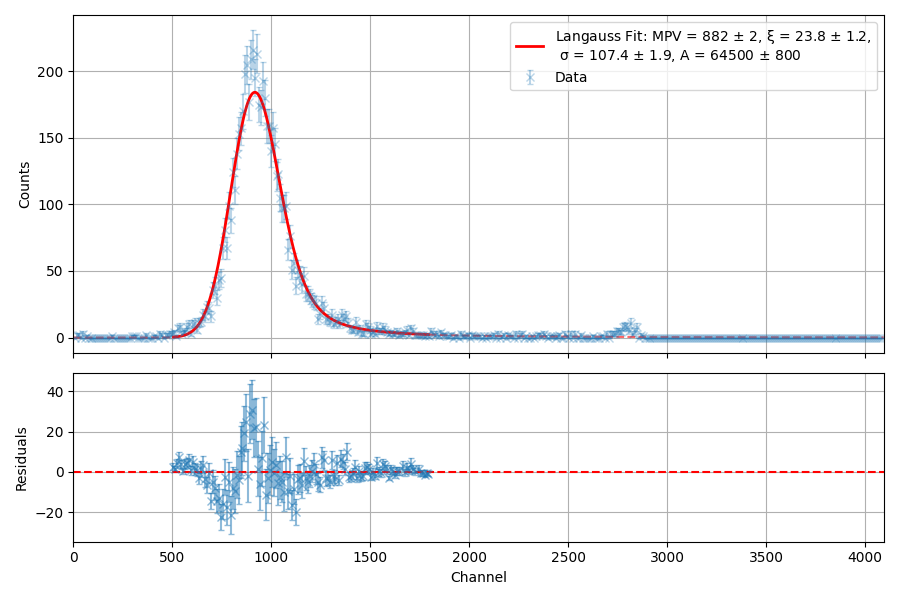

In [71]:
# -------------------------------
# Fit eines Flythrough-Spektrums mit Langauss-Funktion und Residuen
# -------------------------------

# --- Daten einlesen ---
data_63 = read_data('RawData/spectrum/flythrough_5.TKA', cutoff=2)
time_63 = read_data('RawData/spectrum/flythrough_5.TKA', cutoff=0)[0]
channels_63 = np.arange(2, 2 + len(data_63))

# --- Fehler (Poisson) ---
rate_63 = data_63
d_rate_63 = np.sqrt(data_63)

# --- Fitbereich auswählen ---
fit_mask_63 = (channels_63 >= 500) & (channels_63 <= 1800)
x_fit_63 = channels_63[fit_mask_63]
y_fit_63 = rate_63[fit_mask_63]
dy_fit_63 = d_rate_63[fit_mask_63]

# --- Binning (für stabileren Fit) ---
bin_width_63 = 10
x_binned_63, y_binned_63, y_err_63 = bin_data_poisson(
    x_fit_63, y_fit_63, dy_fit_63, bin_width_63
)

# Nur gültige Werte behalten (y_err > 0)
valid_mask_63 = (y_err_63 > 0) & np.isfinite(y_err_63) & np.isfinite(y_binned_63)
x_binned_63 = x_binned_63[valid_mask_63]
y_binned_63 = y_binned_63[valid_mask_63]
y_err_63 = y_err_63[valid_mask_63]

# -------------------------------
# Fit mit iminuit
# -------------------------------
p0_63 = [1430, 30, 190, 100]  # [mpv, xi, sigma, A]
bounds_63 = [(0, None), (0, None), (1e-3, None), (0, None)]

popt_63, perr_63, minuit_63 = fit_with_iminuit(
    x_binned_63,
    y_binned_63,
    model=fit_langauss,
    p0=p0_63,
    bounds=bounds_63,
    verbose=False,
    asymmetric=False
)

# Ergebnisse ausgeben
param_names_63 = ['MPV', 'ξ', 'σ', 'A']
print("Best-fit-Parameter (symmetrisch):")
for name, val, err in zip(param_names_63, popt_63, perr_63):
    print(f"{name:>3} = {val:.3f} ± {err:.3f}")

# -------------------------------
# Feine x-Werte für glatte Fit-Kurve
# -------------------------------
x_plot_63 = np.linspace(min(channels_63), max(channels_63), 2000)
y_plot_63 = fit_langauss(x_plot_63, *popt_63)

# Fitbereich-Grenzen
x_fit_min_63 = x_binned_63[0]
x_fit_max_63 = x_binned_63[-1]

# Bereiche definieren
mask_left_63 = x_plot_63 < x_fit_min_63
mask_mid_63 = (x_plot_63 >= x_fit_min_63) & (x_plot_63 <= x_fit_max_63)
mask_right_63 = x_plot_63 > x_fit_max_63

# -------------------------------
# Plot mit zwei Subplots
# -------------------------------
fig_63, (ax0_63, ax1_63) = plt.subplots(2, 1, figsize=(9,6), sharex=True,
                                        gridspec_kw={'height_ratios':[2,1]})

# --- Daten (gebinnt) ---
x_all_63, y_all_63, yerr_all_63 = bin_data_poisson(channels_63, data_63, d_rate_63, bin_width_63)
ax0_63.errorbar(
    x_all_63, y_all_63, yerr_all_63,
    fmt='x', capsize=2, alpha=0.3, label='Data'
)

# -------------------------------
# Residuen berechnen
# -------------------------------
residues_63 = y_binned_63 - fit_langauss(x_binned_63, *popt_63)
resid_errors_63 = np.sqrt(y_binned_63)

# --- Fit außerhalb links (gestrichelt) ---
ax0_63.plot(x_plot_63[mask_left_63], y_plot_63[mask_left_63], color='red', linestyle='--', alpha=0.6)
# --- Fitbereich (durchgezogen) mit Fit-Werten im Label ---
fit_label_63 = f"Langauss Fit: MPV = {popt_63[0]:.0f} $\pm$ {perr_63[0]:.0f}, ξ = {popt_63[1]:.1f} $\pm$ {perr_63[1]:.1f},\n σ = {popt_63[2]:.1f} $\pm$ {perr_63[2]:.1f}, A = {np.round(popt_63[3], -2):.0f} $\pm$ {np.round(perr_63[3], -2):.0f}"
ax0_63.plot(x_plot_63[mask_mid_63], y_plot_63[mask_mid_63], color='red', linestyle='-', linewidth=2,
            label=fit_label_63)
# --- Fit außerhalb rechts (gestrichelt) ---
ax0_63.plot(x_plot_63[mask_right_63], y_plot_63[mask_right_63], color='red', linestyle='--', alpha=0.6)

# --- Achsen & Legende ---
ax0_63.set_ylabel('Counts')
ax0_63.legend()
ax0_63.grid(True)

# --- Residuen ---
ax1_63.errorbar(x_binned_63, residues_63, yerr=resid_errors_63, fmt='x', capsize=2, alpha=0.5)
ax1_63.axhline(0, color='red', linestyle='--')
ax1_63.set_xlabel('Channel')
ax1_63.set_ylabel('Residuals')
ax1_63.grid(True)
ax1_63.set_xlim(0, max(channels_63))

plt.tight_layout()
plt.savefig('Results/Flythrough_63.pdf')
plt.show()

C:\Users\tabit\AppData\Local\Temp\ipykernel_33484\677955885.py:206: RuntimeWarning: divide by zero encountered in log
  return np.sum(lam - k * np.log(lam))


Best-fit-Parameter (symmetrisch):
MPV = 707.191 ± 1.425
  ξ = 18.611 ± 0.713
  σ = 78.455 ± 1.302
  A = 103014.499 ± 1026.698


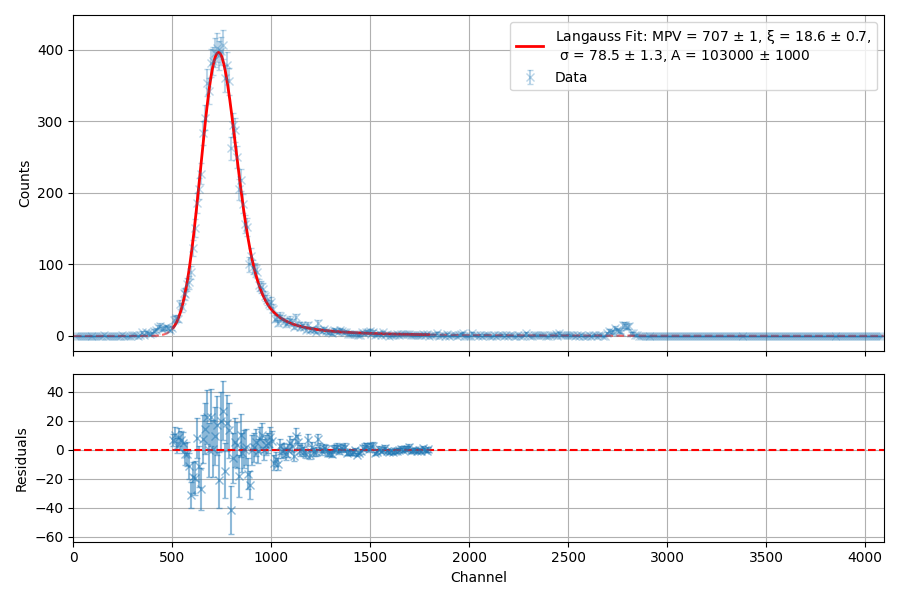

In [72]:
# -------------------------------
# Fit eines Flythrough-Spektrums mit Langauss-Funktion und Residuen
# -------------------------------

# --- Daten einlesen ---
data_50 = read_data('RawData/spectrum/flythrough_3.TKA', cutoff=2)
time_50 = read_data('RawData/spectrum/flythrough_3.TKA', cutoff=0)[0]
channels_50 = np.arange(2, 2 + len(data_50))

# --- Fehler (Poisson) ---
rate_50 = data_50
d_rate_50 = np.sqrt(data_50)

# --- Fitbereich auswählen ---
fit_mask_50 = (channels_50 >= 500) & (channels_50 <= 1800)
x_fit_50 = channels_50[fit_mask_50]
y_fit_50 = rate_50[fit_mask_50]
dy_fit_50 = d_rate_50[fit_mask_50]

# --- Binning (für stabileren Fit) ---
bin_width_50 = 10
x_binned_50, y_binned_50, y_err_50 = bin_data_poisson(
    x_fit_50, y_fit_50, dy_fit_50, bin_width_50
)

# Nur gültige Werte behalten (y_err > 0)
valid_mask_50 = (y_err_50 > 0) & np.isfinite(y_err_50) & np.isfinite(y_binned_50)
x_binned_50 = x_binned_50[valid_mask_50]
y_binned_50 = y_binned_50[valid_mask_50]
y_err_50 = y_err_50[valid_mask_50]

# -------------------------------
# Fit mit iminuit
# -------------------------------
p0_50 = [1430, 30, 190, 100]  # [mpv, xi, sigma, A]
bounds_50 = [(0, None), (0, None), (1e-3, None), (0, None)]

popt_50, perr_50, minuit_50 = fit_with_iminuit(
    x_binned_50,
    y_binned_50,
    model=fit_langauss,
    p0=p0_50,
    bounds=bounds_50,
    verbose=False,
    asymmetric=False
)

# Ergebnisse ausgeben
param_names_50 = ['MPV', 'ξ', 'σ', 'A']
print("Best-fit-Parameter (symmetrisch):")
for name, val, err in zip(param_names_50, popt_50, perr_50):
    print(f"{name:>3} = {val:.3f} ± {err:.3f}")

# -------------------------------
# Feine x-Werte für glatte Fit-Kurve
# -------------------------------
x_plot_50 = np.linspace(min(channels_50), max(channels_50), 2000)
y_plot_50 = fit_langauss(x_plot_50, *popt_50)

# Fitbereich-Grenzen
x_fit_min_50 = x_binned_50[0]
x_fit_max_50 = x_binned_50[-1]

# Bereiche definieren
mask_left_50 = x_plot_50 < x_fit_min_50
mask_mid_50 = (x_plot_50 >= x_fit_min_50) & (x_plot_50 <= x_fit_max_50)
mask_right_50 = x_plot_50 > x_fit_max_50

# -------------------------------
# Plot mit zwei Subplots
# -------------------------------
fig_50, (ax0_50, ax1_50) = plt.subplots(2, 1, figsize=(9,6), sharex=True,
                                        gridspec_kw={'height_ratios':[2,1]})

# --- Daten (gebinnt) ---
x_all_50, y_all_50, yerr_all_50 = bin_data_poisson(channels_50, data_50, d_rate_50, bin_width_50)
ax0_50.errorbar(
    x_all_50, y_all_50, yerr_all_50,
    fmt='x', capsize=2, alpha=0.3, label='Data'
)

# -------------------------------
# Residuen berechnen
# -------------------------------
residues_50 = y_binned_50 - fit_langauss(x_binned_50, *popt_50)
resid_errors_50 = np.sqrt(y_binned_50)

# --- Fit außerhalb links (gestrichelt) ---
ax0_50.plot(x_plot_50[mask_left_50], y_plot_50[mask_left_50], color='red', linestyle='--', alpha=0.6)
# --- Fitbereich (durchgezogen) mit Fit-Werten im Label ---
fit_label_50 = f"Langauss Fit: MPV = {popt_50[0]:.0f} $\pm$ {perr_50[0]:.0f}, ξ = {popt_50[1]:.1f} $\pm$ {perr_50[1]:.1f},\n σ = {popt_50[2]:.1f} $\pm$ {perr_50[2]:.1f}, A = {np.round(popt_50[3], -2):.0f} $\pm$ {np.round(perr_50[3], -2):.0f}"
ax0_50.plot(x_plot_50[mask_mid_50], y_plot_50[mask_mid_50], color='red', linestyle='-', linewidth=2,
            label=fit_label_50)
# --- Fit außerhalb rechts (gestrichelt) ---
ax0_50.plot(x_plot_50[mask_right_50], y_plot_50[mask_right_50], color='red', linestyle='--', alpha=0.6)

# --- Achsen & Legende ---
ax0_50.set_ylabel('Counts')
ax0_50.legend()
ax0_50.grid(True)

# --- Residuen ---
ax1_50.errorbar(x_binned_50, residues_50, yerr=resid_errors_50, fmt='x', capsize=2, alpha=0.5)
ax1_50.axhline(0, color='red', linestyle='--')
ax1_50.set_xlabel('Channel')
ax1_50.set_ylabel('Residuals')
ax1_50.grid(True)
ax1_50.set_xlim(0, max(channels_50))

plt.tight_layout()
plt.savefig('Results/Flythrough_50.pdf')
plt.show()

C:\Users\tabit\AppData\Local\Temp\ipykernel_33484\677955885.py:206: RuntimeWarning: divide by zero encountered in log
  return np.sum(lam - k * np.log(lam))
C:\Users\tabit\AppData\Local\Temp\ipykernel_33484\677955885.py:206: RuntimeWarning: divide by zero encountered in log
  return np.sum(lam - k * np.log(lam))
C:\Users\tabit\AppData\Local\Temp\ipykernel_33484\677955885.py:206: RuntimeWarning: divide by zero encountered in log
  return np.sum(lam - k * np.log(lam))
C:\Users\tabit\AppData\Local\Temp\ipykernel_33484\677955885.py:206: RuntimeWarning: divide by zero encountered in log
  return np.sum(lam - k * np.log(lam))


Best-fit-Parameter (symmetrisch):
MPV = 360.351 ± 0.971
  ξ = 8.366 ± 0.422
  σ = 45.817 ± 0.725
  A = 64505.790 ± 810.634


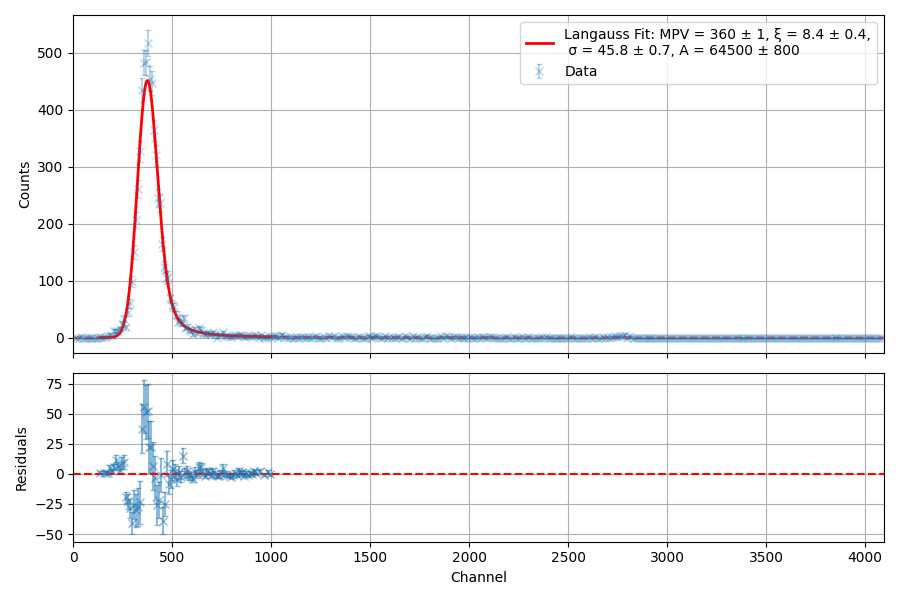

In [73]:
# -------------------------------
# Fit eines Flythrough-Spektrums mit Langauss-Funktion und Residuen
# -------------------------------

# --- Daten einlesen ---
data_25 = read_data('RawData/spectrum/flythrough_2.TKA', cutoff=2)
time_25 = read_data('RawData/spectrum/flythrough_2.TKA', cutoff=0)[0]
channels_25 = np.arange(2, 2 + len(data_25))

# --- Fehler (Poisson) ---
rate_25 = data_25
d_rate_25 = np.sqrt(data_25)

# --- Fitbereich auswählen ---
fit_mask_25 = (channels_25 >= 110) & (channels_25 <= 1000)
x_fit_25 = channels_25[fit_mask_25]
y_fit_25 = rate_25[fit_mask_25]
dy_fit_25 = d_rate_25[fit_mask_25]

# --- Binning (für stabileren Fit) ---
bin_width_25 = 10
x_binned_25, y_binned_25, y_err_25 = bin_data_poisson(
    x_fit_25, y_fit_25, dy_fit_25, bin_width_25
)

# Nur gültige Werte behalten (y_err > 0)
valid_mask_25 = (y_err_25 > 0) & np.isfinite(y_err_25) & np.isfinite(y_binned_25)
x_binned_25 = x_binned_25[valid_mask_25]
y_binned_25 = y_binned_25[valid_mask_25]
y_err_25 = y_err_25[valid_mask_25]

# -------------------------------
# Fit mit iminuit
# -------------------------------
p0_25 = [300, 30, 190, 100]  # [mpv, xi, sigma, A]
bounds_25 = [(0, None), (0, None), (1e-3, None), (0, None)]

popt_25, perr_25, minuit_25 = fit_with_iminuit(
    x_binned_25,
    y_binned_25,
    model=fit_langauss,
    p0=p0_25,
    bounds=bounds_25,
    verbose=False,
    asymmetric=False
)

# Ergebnisse ausgeben
param_names_25 = ['MPV', 'ξ', 'σ', 'A']
print("Best-fit-Parameter (symmetrisch):")
for name, val, err in zip(param_names_25, popt_25, perr_25):
    print(f"{name:>3} = {val:.3f} ± {err:.3f}")

# -------------------------------
# Feine x-Werte für glatte Fit-Kurve
# -------------------------------
x_plot_25 = np.linspace(min(channels_25), max(channels_25), 2000)
y_plot_25 = fit_langauss(x_plot_25, *popt_25)

# Fitbereich-Grenzen
x_fit_min_25 = x_binned_25[0]
x_fit_max_25 = x_binned_25[-1]

# Bereiche definieren
mask_left_25 = x_plot_25 < x_fit_min_25
mask_mid_25 = (x_plot_25 >= x_fit_min_25) & (x_plot_25 <= x_fit_max_25)
mask_right_25 = x_plot_25 > x_fit_max_25

# -------------------------------
# Plot mit zwei Subplots
# -------------------------------
fig_25, (ax0_25, ax1_25) = plt.subplots(2, 1, figsize=(9,6), sharex=True,
                                        gridspec_kw={'height_ratios':[2,1]})

# --- Daten (gebinnt) ---
x_all_25, y_all_25, yerr_all_25 = bin_data_poisson(channels_25, data_25, d_rate_25, bin_width_25)
ax0_25.errorbar(
    x_all_25, y_all_25, yerr_all_25,
    fmt='x', capsize=2, alpha=0.3, label='Data'
)

# -------------------------------
# Residuen berechnen
# -------------------------------
residues_25 = y_binned_25 - fit_langauss(x_binned_25, *popt_25)
resid_errors_25 = np.sqrt(y_binned_25)

# --- Fit außerhalb links (gestrichelt) ---
ax0_25.plot(x_plot_25[mask_left_25], y_plot_25[mask_left_25], color='red', linestyle='--', alpha=0.6)
# --- Fitbereich (durchgezogen) mit Fit-Werten im Label ---
fit_label_25 = f"Langauss Fit: MPV = {popt_25[0]:.0f} ± {perr_25[0]:.0f}, ξ = {popt_25[1]:.1f} ± {perr_25[1]:.1f},\n σ = {popt_25[2]:.1f} ± {perr_25[2]:.1f}, A = {np.round(popt_25[3], -2):.0f} ± {np.round(perr_25[3], -2):.0f}"
ax0_25.plot(x_plot_25[mask_mid_25], y_plot_25[mask_mid_25], color='red', linestyle='-', linewidth=2,
            label=fit_label_25)
# --- Fit außerhalb rechts (gestrichelt) ---
ax0_25.plot(x_plot_25[mask_right_25], y_plot_25[mask_right_25], color='red', linestyle='--', alpha=0.6)

# --- Achsen & Legende ---
ax0_25.set_ylabel('Counts')
ax0_25.legend()
ax0_25.grid(True)

# --- Residuen ---
ax1_25.errorbar(x_binned_25, residues_25, yerr=resid_errors_25, fmt='x', capsize=2, alpha=0.5)
ax1_25.axhline(0, color='red', linestyle='--')
ax1_25.set_xlabel('Channel')
ax1_25.set_ylabel('Residuals')
ax1_25.grid(True)
ax1_25.set_xlim(0, max(channels_25))

plt.tight_layout()
plt.savefig('Results/Flythrough_25.pdf')
plt.show()

In [97]:
mpv_all_values = [popt_100[0], popt_63[0] - pedestal_63 + pedestal_100, popt_50[0] - pedestal_50 + pedestal_100, popt_25[0] - pedestal_25 + pedestal_100]
def quadrativ_addition(a, b, c = None):
    if c is not None:
        return np.sqrt(a**2 + b**2 + c**2)
    else:
        return np.sqrt(a**2 + b**2)

dmpv_all_values = [perr_100[0], quadrativ_addition(perr_63[0], dpedestal_63, dpedestal_100), quadrativ_addition(perr_50[0], dpedestal_50, dpedestal_100), quadrativ_addition(perr_25[0], dpedestal_25, dpedestal_100)]

### theoretical values

In [98]:
MIP_rhox = 1.95 # MeV cm^2 g^-1
rho = 0.87 # g cm^-3 density of liquid scintillator
s = 85 # cm mean free path in tank

dMIP_rhox = 0.05
drho = 0.01
ds = 5 

energy_MIP = MIP_rhox * rho * s
denergy_MIP = np.sqrt((dMIP_rhox * rho * s)**2 + (MIP_rhox * drho * s)**2 + (MIP_rhox * rho * ds)**2)
print(energy_MIP, denergy_MIP)

energy_MIP_all = [energy_MIP, 0.63 * energy_MIP, 0.50 * energy_MIP, 0.25 * energy_MIP]
denergy_MIP_all = [denergy_MIP, 0.63 * denergy_MIP, 0.50 * denergy_MIP, 0.25 * denergy_MIP]


144.2025 9.400617998302026


m = 0.144785869230335 ± 0.0028988099660507455
b = -60.43199924274947 ± 2.331298747526799


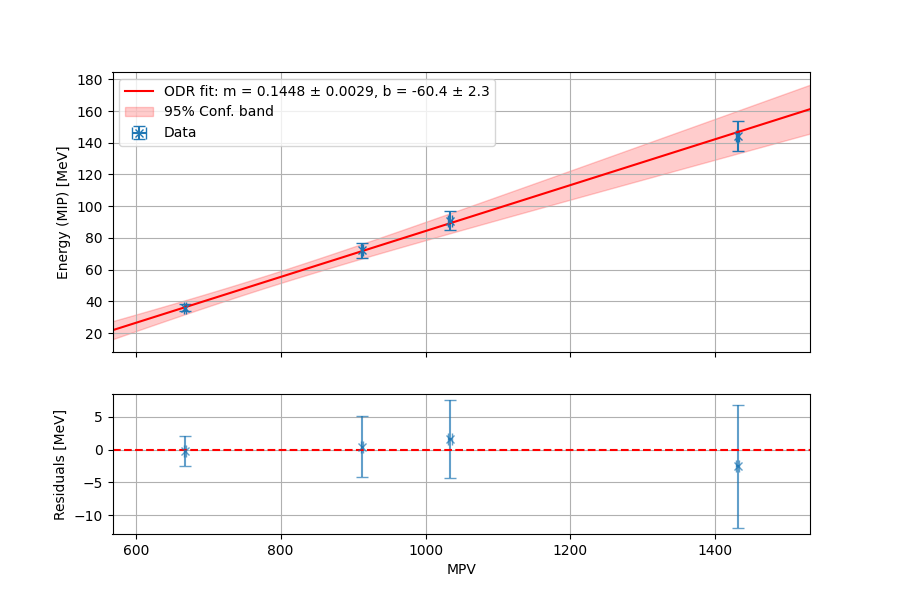

In [99]:
# Datenobjekt mit Unsicherheiten
data = RealData(
    mpv_all_values,
    energy_MIP_all,
    sx=dmpv_all_values,
    sy=denergy_MIP_all
)

# Modell
model = Model(linear_func)

# Initial guesses
beta0 = [1, 0]

# ODR
odr = ODR(data, model, beta0=beta0)
out = odr.run()

# Fitparameter
m_energycalib, b_energycalib = out.beta
dm_energycalib, db_energycalib = out.sd_beta

print(f"m = {m_energycalib} ± {dm_energycalib}")
print(f"b = {b_energycalib} ± {db_energycalib}")

# Fitkurve
x_fit = np.linspace(min(mpv_all_values)-100, max(mpv_all_values)+100, 500)
y_fit = m_energycalib*x_fit + b_energycalib

# Kovarianzmatrix aus ODR
cov = out.cov_beta  # 2x2 Matrix: [[var_m, cov_mb],[cov_mb, var_b]]
var_m = cov[0,0]
var_b = cov[1,1]
cov_mb = cov[0,1]

# Unsicherheit auf y(x)
sigma_y = np.sqrt(var_b + (x_fit**2)*var_m + 2*x_fit*cov_mb)

# 95% Konfidenzband
t = 1.96
y_upper = y_fit + t*sigma_y
y_lower = y_fit - t*sigma_y


# -------------------------------
# ODR-Fit mit Residuen
# -------------------------------

# Fitkurve vorbereiten
x_fit = np.linspace(min(mpv_all_values)-100, max(mpv_all_values)+100, 500)
y_fit = m_energycalib*x_fit + b_energycalib

# Residuen berechnen
# Sicherstellen, dass die Daten Arrays sind
mpv_all_values = np.array(mpv_all_values)
energy_MIP_all = np.array(energy_MIP_all)
dmpv_all_values = np.array(dmpv_all_values)
denergy_MIP_all = np.array(denergy_MIP_all)
residues = energy_MIP_all - (m_energycalib*mpv_all_values + b_energycalib)

# Unsicherheit auf y(x)
cov = out.cov_beta  # 2x2 Matrix: [[var_m, cov_mb],[cov_mb, var_b]]
var_m = cov[0,0]
var_b = cov[1,1]
cov_mb = cov[0,1]
sigma_y = np.sqrt(var_b + (x_fit**2)*var_m + 2*x_fit*cov_mb)

# 95% Konfidenzband
t = 1.96
y_upper = y_fit + t*sigma_y
y_lower = y_fit - t*sigma_y

# -------------------------------
# Plot mit zwei Subplots
# -------------------------------
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(9,6), sharex=True,
                                        gridspec_kw={'height_ratios':[2,1]})

# --- Oberer Plot: Fit mit Konfidenzband ---
ax0.errorbar(
    mpv_all_values,
    energy_MIP_all,
    xerr=dmpv_all_values,
    yerr=denergy_MIP_all,
    fmt='x',
    capsize=4,
    label='Data'
)
ax0.plot(x_fit, y_fit, 'r', label=f'ODR fit: m = {m_energycalib:.4f} ± {dm_energycalib:.4f}, b = {b_energycalib:.1f} ± {db_energycalib:.1f}')
ax0.fill_between(x_fit, y_lower, y_upper, color='red', alpha=0.2, label='95% Conf. band')
ax0.set_ylabel("Energy (MIP) [MeV]")
ax0.grid(True)
ax0.legend()

# --- Unterer Plot: Residuen ---
ax1.errorbar(
    mpv_all_values,
    residues,
    yerr=denergy_MIP_all,
    xerr = dmpv_all_values,
    fmt='x',
    capsize=4,
    alpha=0.7
)
ax1.axhline(0, color='red', linestyle='--')
ax1.set_xlabel("MPV")
ax1.set_ylabel("Residuals [MeV]")
ax1.grid(True)

# # Plot
# plt.figure(figsize=(8,5))
# plt.errorbar(
#     mpv_all_values,
#     energy_MIP_all,
#     xerr=dmpv_all_values,
#     yerr=denergy_MIP_all,
#     fmt='x',
#     capsize=4,
#     label='Data'
# )
# plt.plot(x_fit, y_fit, 'r', label=f'ODR fit: m = {m_energycalib:.4f} ± {dm_energycalib:.4f}, b = {b_energycalib:.1f} ± {db_energycalib:.1f}')
# plt.fill_between(x_fit, y_lower, y_upper, color='red', alpha=0.2, label='95% Conf. band')
# plt.xlabel("MPV")
# plt.ylabel("Energy (MIP) [MeV]")
plt.xlim(min(mpv_all_values)-100, max(mpv_all_values)+100)
# plt.legend()
plt.savefig('Results/EnergyCalibration.pdf')
# plt.show()

In [ ]:
def channel_to_energy_with_error(channel, m = m_energycalib, b = b_energycalib, dm = dm_energycalib, db = db_energycalib, dchannel=0):
    """
    Kalibrierungsfunktion mit vollständiger Unsicherheitsabschätzung

    Parameters
    ----------
    channel : float or array-like
        Kanalwerte
    m, b : float
        Fit-Parameter der Kalibration
    dm, db : float
        Unsicherheiten der Fit-Parameter
    dchannel : float or array-like
        Unsicherheit der Kanalwerte (z.B. Pedestal-Fehler)

    Returns
    -------
    energy : float or array-like
        Energie
    energy_err : float or array-like
        Unsicherheit der Energie
    """
    channel = np.array(channel)

    energy = m * channel + b

    energy_err = np.sqrt(
        (m * dchannel)**2 +  
        (channel * dm)**2 +
        db**2
    )

    return energy, energy_err



In [196]:
channel_to_energy_with_error(852, m = m_energycalib, b = b_energycalib, dm = dm_energycalib, db = db_energycalib, dchannel=0)

(62.925561341495964, 3.3962916815092177)

## Time Spectrum Calibration

Delay = 2.44 ± 0.0022 µs


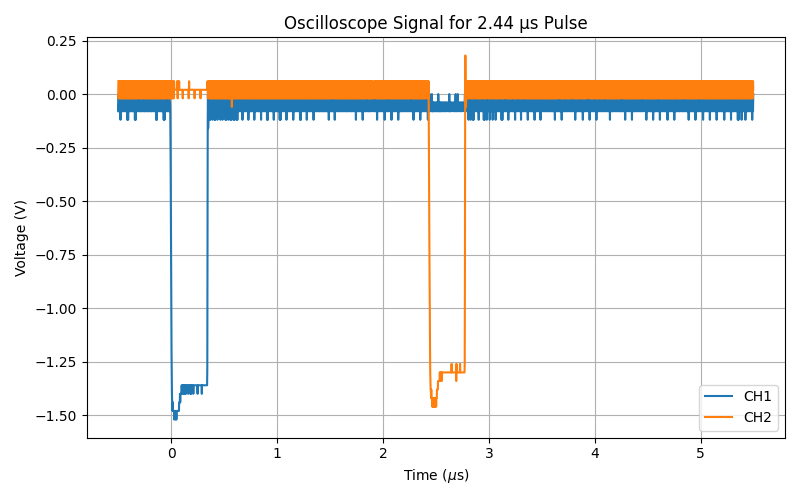

Delay = 4.54 ± 0.0019 µs


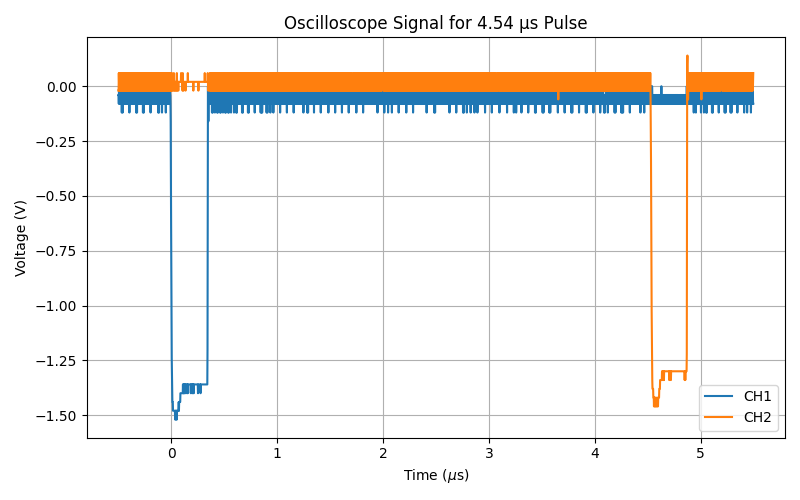

Delay = 6.29 ± 0.0023 µs


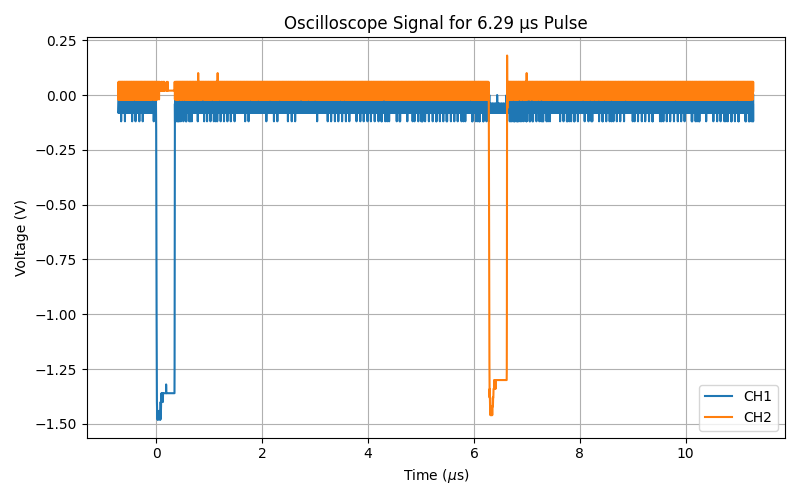

Delay = 8.65 ± 0.0024 µs


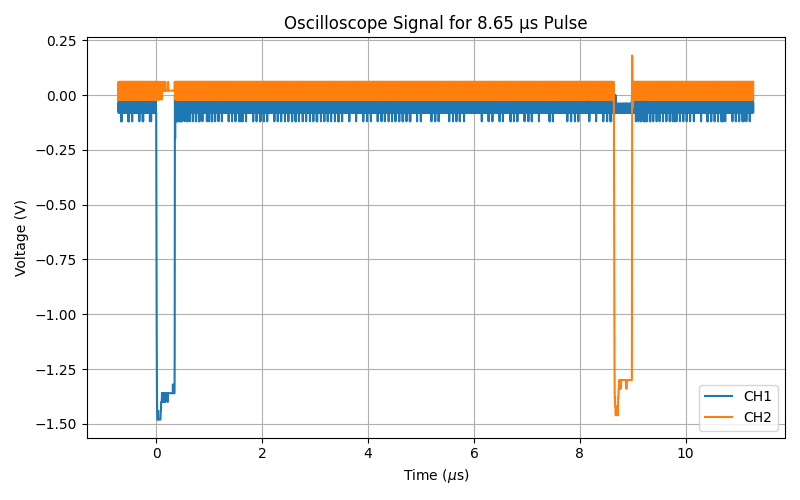

Delay = 10.69 ± 0.0024 µs


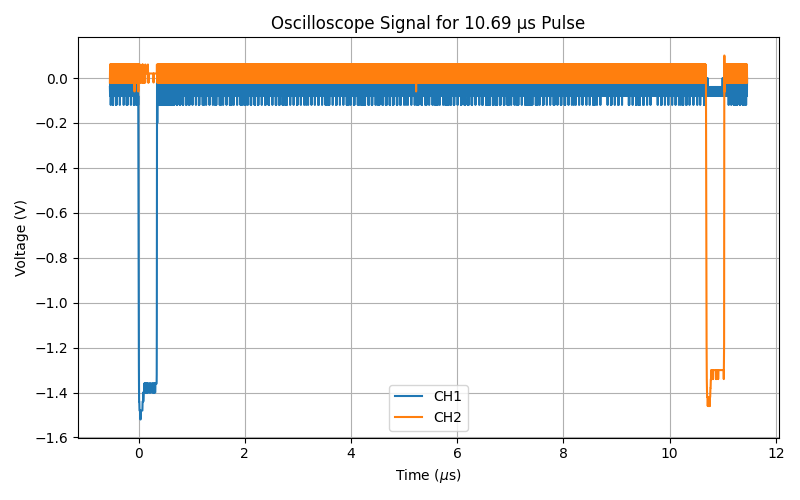

In [84]:
files = ["NewFile1.csv", "NewFile2.csv", "NewFile3.csv", "NewFile4.csv", "NewFile5.csv"]
pulse_times_us = [2, 4, 6, 8, 10]  # in µs
delay_values = []
delay_unc = []

for file in files:

    t, ch1, ch2 = load_rigol_two_channel(f"RawData/timecalib5/{file}")

    # 50 %
    t1_50 = threshold_time(t, ch1, 0.5)
    t2_50 = threshold_time(t, ch2, 0.5)

    # 40 %
    t1_40 = threshold_time(t, ch1, 0.4)
    t2_40 = threshold_time(t, ch2, 0.4)

    # 60 %
    t1_60 = threshold_time(t, ch1, 0.6)
    t2_60 = threshold_time(t, ch2, 0.6)

    delay = t2_50 - t1_50

    sigma_t1 = abs(t1_60 - t1_40) / 2
    sigma_t2 = abs(t2_60 - t2_40) / 2

    sigma_delay = np.sqrt(sigma_t1**2 + sigma_t2**2)

    print(f"Delay = {delay*1e6:.2f} ± {sigma_delay*1e6:.4f} µs")

    delay_values.append(delay)
    delay_values_us = np.array([i*1e6 for i in delay_values])
    delay_unc.append(sigma_delay)
    delay_unc_us= np.array([i*1e6 for i in delay_unc])
    plt.figure(figsize=(8,5)) 
    plt.plot(t*1e6, ch1, label="CH1") 
    plt.plot(t*1e6, ch2, label="CH2") 
    plt.xlabel("Time ($\mu$s)") 
    plt.ylabel("Voltage (V)") 
    plt.title(f"Oscilloscope Signal for {delay*1e6:.2f} µs Pulse") 
    #plt.savefig(f'Results/')
    plt.legend() 
    plt.grid() 
    plt.tight_layout() 
    plt.show()

[910, 1643, 2254, 3079, 3791]


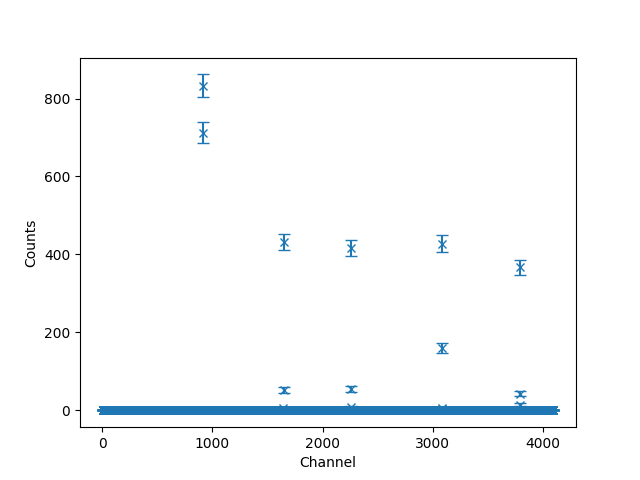

In [86]:
# import time calibration spectrum

time_calibration_spectrum = read_data('RawData/spectrum/time_calibration_5.TKA', cutoff = 2) # 2
time_calibration_channel = np.arange(2, 2 + len(time_calibration_spectrum))
time_calibration_uncertainty = np.array([np.sqrt(x) for x in time_calibration_spectrum])

# find peaks
peaks = np.where(time_calibration_spectrum > 20)[0]

# Gruppen bilden
groups = []
current = [peaks[0]]

for p in peaks[1:]:
    if p - current[-1] <= 1:
        current.append(p)
    else:
        groups.append(current)
        current = [p]

groups.append(current)

peaks_calibration_time = []
dpeaks_calibration_time = []

for g in groups:
    g = np.array(g)

    heights = time_calibration_spectrum[g]

    # höhengewichteter Mittelwert
    mean = np.sum(g * heights) / np.sum(heights)

    # Unsicherheit aus halber Peakbreite
    unc = (np.max(g) - np.min(g)) / 2

    # ganze Channel
    unc = int(np.round(unc))
    mean = int(np.round(mean))

    peaks_calibration_time.append((mean))
    dpeaks_calibration_time.append((unc))

print(peaks_calibration_time)
dpeaks_calibration_time = [1, 1, 1, 1, 1]


#time_calibration_fit_results = []
plt.figure()
plt.errorbar(time_calibration_channel, time_calibration_spectrum, yerr=time_calibration_uncertainty, fmt='x', capsize=4)
plt.xlabel('Channel')
plt.ylabel('Counts')
plt.savefig('Results/timecalib5.pdf')



In [88]:
#### odr fit

Slope = 0.002864 ± 0.000002
Intercept = -0.17 ± 0.00


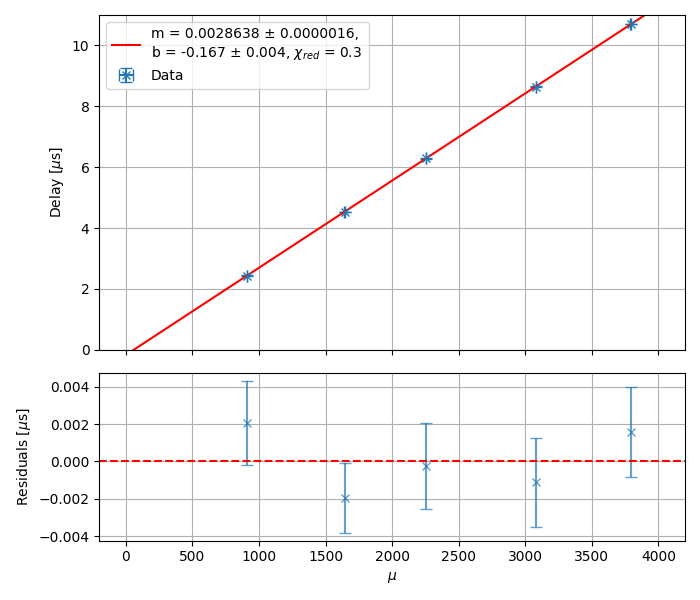

In [209]:
mean_time_calibration = peaks_calibration_time
error_mean_time_calibration = dpeaks_calibration_time


# RealData mit x-Fehler
data = RealData(mean_time_calibration, delay_values_us,
                sx=error_mean_time_calibration, sy=delay_unc_us)  # y-Fehler None, nur x-Fehler

# Modell und ODR-Objekt
linear_model = Model(linear_func)
odr = ODR(data, linear_model, beta0=[0.001, 0])  # Startwerte m, b

# Fit durchführen
output = odr.run()

m_odr, b_odr = output.beta
dm_odr, db_odr = np.sqrt(np.diag(output.cov_beta))

print(f"Slope = {m_odr:.6f} ± {dm_odr:.6f}")
print(f"Intercept = {b_odr:.2f} ± {db_odr:.2f}")

# Fit-Kurve für Plot
x_fit = np.linspace(0, 4000, 10000)
y_fit = linear_func([m_odr, b_odr], x_fit)



# -------------------------------
# Residuen berechnen
# -------------------------------
mean_time_calibration = np.array(mean_time_calibration)
delay_values_us = np.array(delay_values_us)
delay_unc_us = np.array(delay_unc_us)

residuals = delay_values_us - (m_odr*mean_time_calibration + b_odr)

# -------------------------------
# Plot mit zwei Subplots
# -------------------------------
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(7,6), sharex=True,
                               gridspec_kw={'height_ratios':[2,1]})

# --- Oberer Plot: Fit ---
ax0.errorbar(mean_time_calibration, delay_values_us,
             xerr=error_mean_time_calibration, yerr=delay_unc_us,
             fmt='x', capsize=4, label='Data')

ax0.plot(x_fit, y_fit, 'r-',
         label=f'm = {m_odr:.7f} ± {dm_odr:.7f}, \n'
               f'b = {b_odr:.3f} ± {db_odr:.3f}, '
               f'$\chi_{{red}}$ = {output.res_var:.1f}')

ax0.set_ylabel('Delay [$\\mu$s]')
ax0.set_ylim(0, 11)
ax0.grid()
ax0.legend()

# --- Unterer Plot: Residuen ---
ax1.errorbar(mean_time_calibration, residuals,
             yerr=delay_unc_us,
             fmt='x', capsize=4, alpha=0.7)

ax1.axhline(0, color='red', linestyle='--')
ax1.set_xlabel('$\\mu$')
ax1.set_ylabel('Residuals [$\\mu$s]')
ax1.grid()

plt.tight_layout()
plt.savefig('Results/fit_timecalib5.pdf')
plt.show()
# # Plot
# plt.figure()
# plt.errorbar(mean_time_calibration, delay_values_us, xerr=error_mean_time_calibration, yerr = delay_unc_us, fmt='x', capsize=4, label='Data')
# plt.plot(x_fit, y_fit, 'r-', label=f'm = {m_odr:.7f} ± {dm_odr:.7f}, b = {b_odr:.3f} ± {db_odr:.3f}, $\chi_{{red}}$ = {output.res_var:.1f}')
# plt.xlabel('$\mu$')
# plt.ylabel('Delay [$\mu$s]')
# plt.ylim(0, 11)
# # plt.xlim(2000, 4000)
# plt.grid()
# plt.legend()
# plt.tight_layout()
# plt.savefig('Results/fit_timecalib5.pdf')
# plt.show()

In [211]:
def mu_to_delay_with_error(mu, dmu, m, b, dm, db):
    """
    Kalibrierungsfunktion mit Unsicherheitsabschätzung.
    
    Parameters
    ----------
    mu : float or array-like
        Gemessener Mittelwert aus dem Channel (mu)
    m, b : float
        Fit-Parameter des linearen Fits
    dm, db : float
        Unsicherheiten der Fit-Parameter
    
    Returns
    -------
    delay : float or array-like
        Kalibrierter Delay-Wert in µs
    delay_err : float or array-like
        Unsicherheit des Delay-Werts in µs
    """
    mu = np.array(mu)  # für Arrays kompatibel
    delay = m * mu + b
    delay_err = np.sqrt( (mu * dm)**2 + (dmu * m)**2 + db**2 )
    return delay, delay_err



### Calibration with Function Generator

Delay = 0.56 ± 0.0006 µs


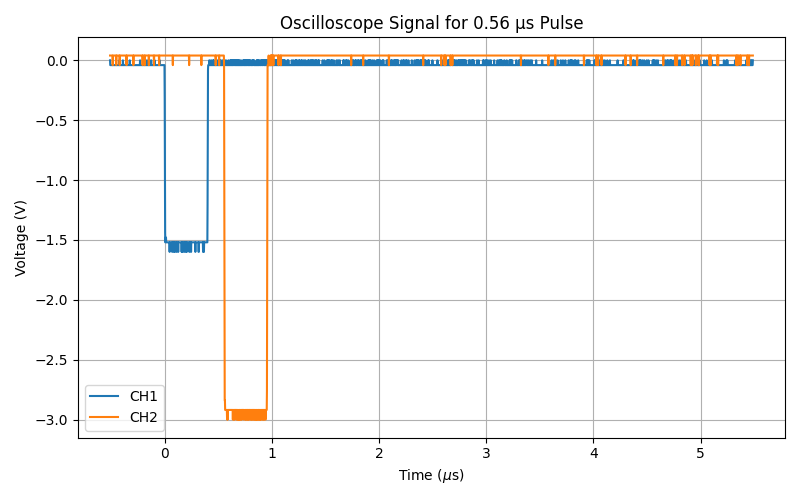

Delay = 1.11 ± 0.0006 µs


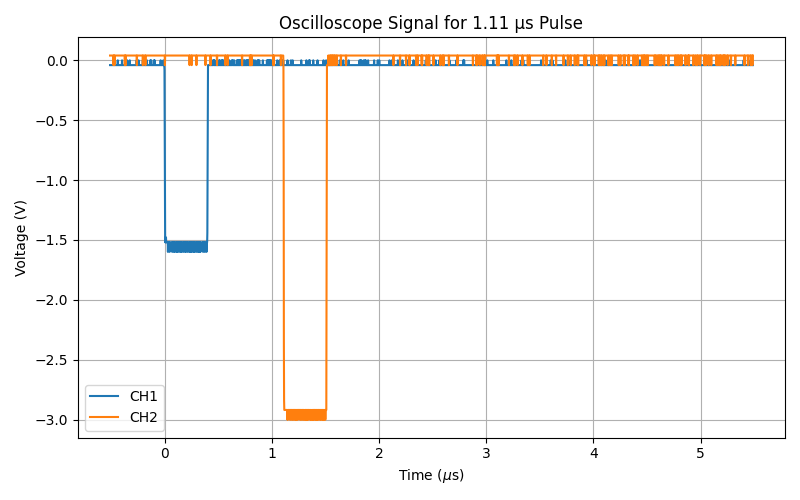

Delay = 1.67 ± 0.0006 µs


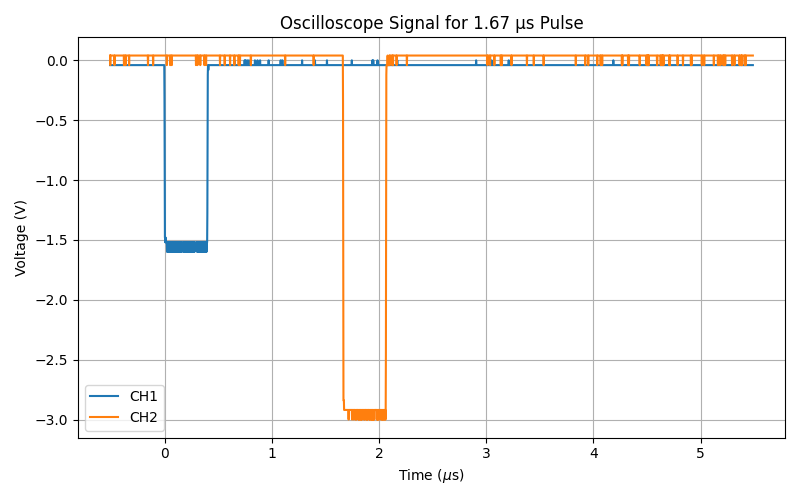

Delay = 2.22 ± 0.0006 µs


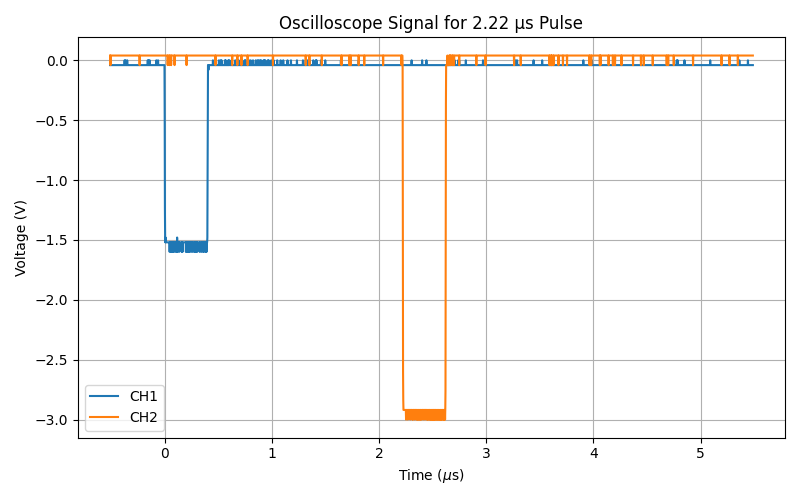

Delay = 2.78 ± 0.0006 µs


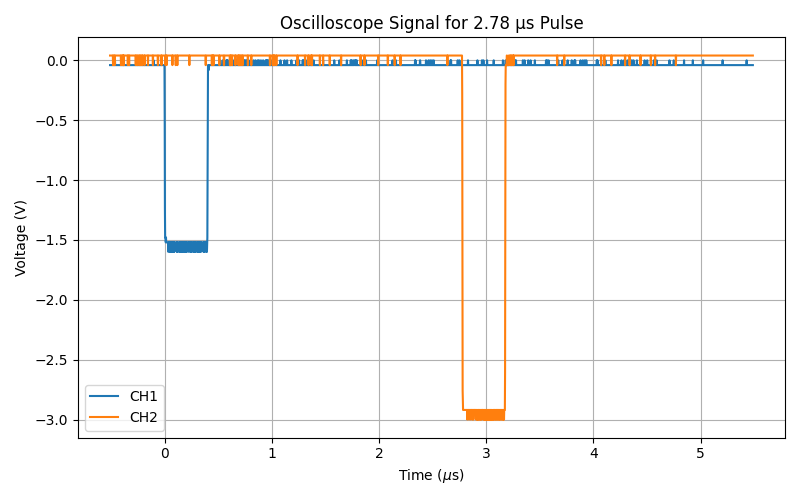

Delay = 5.55 ± 0.0006 µs


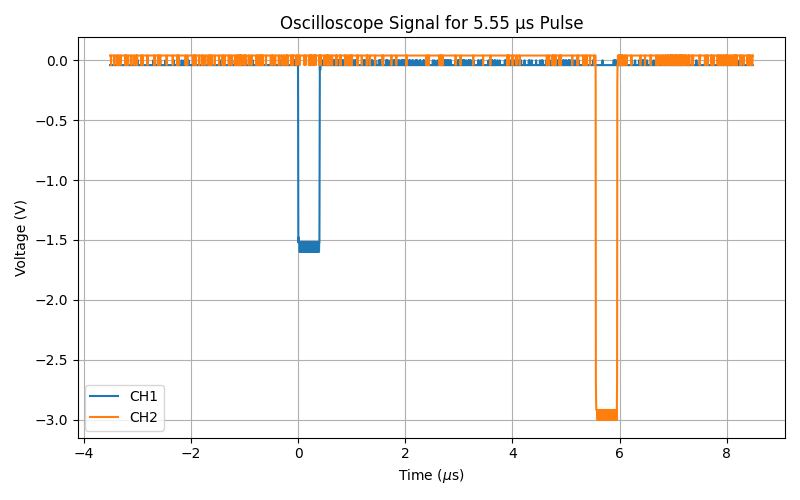

Delay = 8.34 ± 0.0015 µs


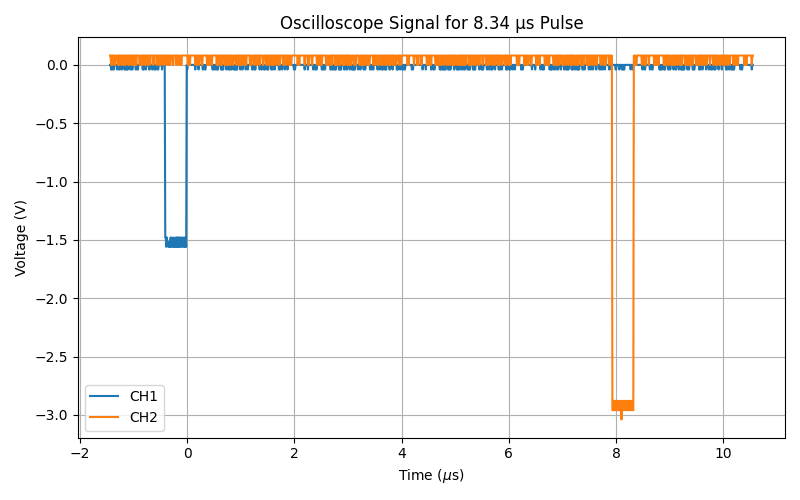

In [92]:
files = ["NewFile1.csv", "NewFile2.csv", "NewFile3.csv", "NewFile4.csv", "NewFile5.csv", "NewFile6.csv", "NewFile7.csv"]
#pulse_times_us = [2, 4, 6, 8, 10]  # in µs
delay_values_fg = []
delay_unc_fg = []


for file in files:

    t, ch1, ch2 = load_rigol_two_channel(f"RawData/timecalib3/{file}")

    # 50 %
    t1_50 = threshold_time(t, ch1, 0.5)
    t2_50 = threshold_time(t, ch2, 0.5)

    # 40 %
    t1_40 = threshold_time(t, ch1, 0.4)
    t2_40 = threshold_time(t, ch2, 0.4)

    # 60 %
    t1_60 = threshold_time(t, ch1, 0.6)
    t2_60 = threshold_time(t, ch2, 0.6)

    delay = t2_50 - t1_50

    sigma_t1 = abs(t1_60 - t1_40) / 2
    sigma_t2 = abs(t2_60 - t2_40) / 2

    sigma_delay = np.sqrt(sigma_t1**2 + sigma_t2**2)

    print(f"Delay = {delay*1e6:.2f} ± {sigma_delay*1e6:.4f} µs")

    delay_values_fg.append(delay)
    delay_values_us_fg = np.array([i*1e6 for i in delay_values_fg])
    delay_unc_fg.append(sigma_delay)
    delay_unc_us_fg = np.array([i*1e6 for i in delay_unc_fg])
    plt.figure(figsize=(8,5)) 
    plt.plot(t*1e6, ch1, label="CH1") 
    plt.plot(t*1e6, ch2, label="CH2") 
    plt.xlabel("Time ($\mu$s)") 
    plt.ylabel("Voltage (V)") 
    plt.title(f"Oscilloscope Signal for {delay*1e6:.2f} µs Pulse") 
    plt.legend() 
    plt.grid() 
    plt.tight_layout() 
    plt.show()

[5, 3, 2, 4, 4, 11, 2]


<ErrorbarContainer object of 3 artists>

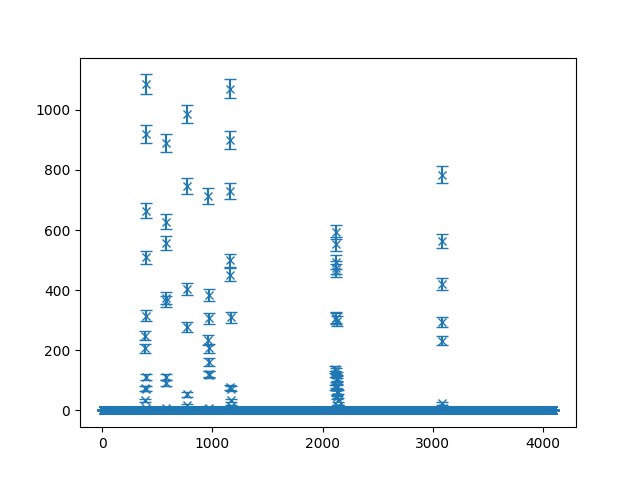

In [93]:
time_calibration_spectrum_fg = read_data('RawData/spectrum/time_calibration_3.TKA', cutoff = 2)
time_calibration_channel_fg = np.arange(2, 2 + len(time_calibration_spectrum_fg))
time_calibration_uncertainty_fg = np.array([np.sqrt(x) for x in time_calibration_spectrum_fg])

# find peaks
peaks_fg = np.where(time_calibration_spectrum_fg > 20)[0]

# Gruppen bilden
groups_fg = []
current_fg = [peaks_fg[0]]

for p in peaks_fg[1:]:
    if p - current_fg[-1] <= 1:
        current_fg.append(p)
    else:
        groups_fg.append(current_fg)
        current_fg = [p]

groups_fg.append(current_fg)

peaks_calibration_time_fg = []
dpeaks_calibration_time_fg = []

for g in groups_fg:
    g = np.array(g)

    heights_fg = time_calibration_spectrum_fg[g]

    # höhengewichteter Mittelwert
    mean_fg = np.sum(g * heights_fg) / np.sum(heights_fg)

    # Unsicherheit aus halber Peakbreite
    unc_fg = (np.max(g) - np.min(g)) / 2

    # ganze Channel
    unc_fg = int(np.round(unc_fg))
    mean_fg = int(np.round(mean_fg))

    peaks_calibration_time_fg.append((mean_fg))
    dpeaks_calibration_time_fg.append((unc_fg))

print(dpeaks_calibration_time_fg)

#dpeaks_calibration_time_fg = [1, 1, 1, 1, 1]


#time_calibration_fit_results = []
plt.figure()
plt.errorbar(time_calibration_channel_fg, time_calibration_spectrum_fg, yerr=time_calibration_uncertainty_fg, fmt='x', capsize=4)



Slope = 0.002885 ± 0.000003
Intercept = -0.55 ± 0.01


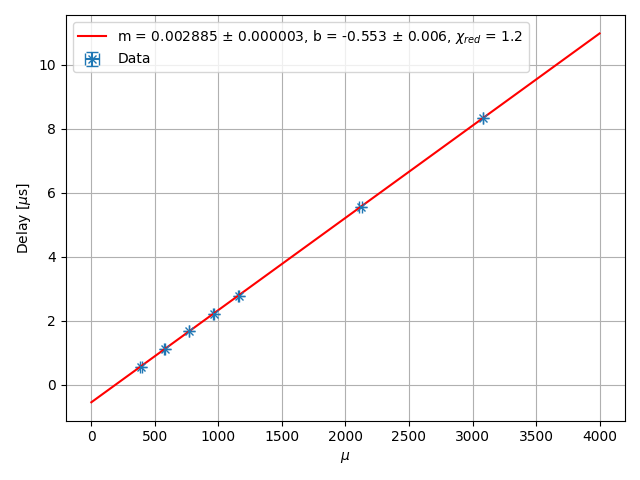

In [95]:
mean_time_calibration_fg = peaks_calibration_time_fg
error_mean_time_calibration_fg = dpeaks_calibration_time_fg

data_fg = RealData(mean_time_calibration_fg, delay_values_us_fg,
                sx=error_mean_time_calibration_fg, sy=delay_unc_us_fg) 

# Modell und ODR-Objekt
linear_model = Model(linear_func)
odr = ODR(data_fg, linear_model, beta0=[0.001, 0])  # Startwerte m, b

# Fit durchführen
output_fg = odr.run()

m_odr_fg, b_odr_fg = output_fg.beta
dm_odr_fg, db_odr_fg = np.sqrt(np.diag(output_fg.cov_beta))

print(f"Slope = {m_odr_fg:.6f} ± {dm_odr_fg:.6f}")
print(f"Intercept = {b_odr_fg:.2f} ± {db_odr_fg:.2f}")

# Fit-Kurve für Plot
x_fit_fg = np.linspace(0, 4000, 10000)
y_fit_fg = linear_func([m_odr_fg, b_odr_fg], x_fit_fg)

# Plot
plt.figure()
plt.errorbar(mean_time_calibration_fg, delay_values_us_fg, xerr=error_mean_time_calibration_fg, yerr = delay_unc_us_fg, fmt='x', capsize=4, label='Data')
plt.plot(x_fit_fg, y_fit_fg, 'r-', label=f'm = {m_odr_fg:.6f} ± {dm_odr_fg:.6f}, b = {b_odr_fg:.3f} ± {db_odr_fg:.3f}, $\chi_{{red}}$ = {output_fg.res_var:.1f}')
plt.xlabel('$\mu$')
plt.ylabel('Delay [$\mu$s]')
#plt.ylim(0, 11)
# plt.xlim(2000, 4000)
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig('Results/timecalibration_fg.pdf')
plt.show()

## Background

<ErrorbarContainer object of 3 artists>

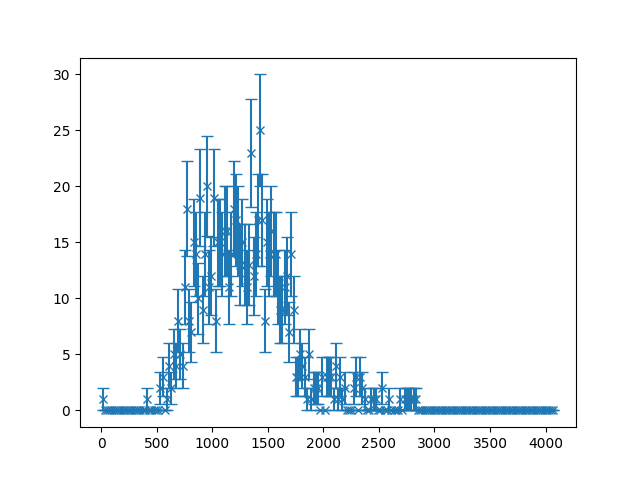

In [161]:
# background beta spectrum

beta_background = read_data('RawData/spectrum/beta_background_3.TKA', cutoff=2).astype(float)
beta_background_time = read_data('RawData/spectrum/beta_background_3.TKA', cutoff=0)[0]
beta_background_channel = np.arange(2, 2 + len(beta_background))
beta_background_time = np.float64(beta_background_time)

beta_background_uncertainty = np.sqrt(beta_background) 


# bin the data to reduce noise
binned_beta_background_channel, binned_beta_background, binned_error_beta_background = bin_data_poisson(
    beta_background_channel, beta_background, yerr = beta_background_uncertainty, bin_width = 20)

# plot the binned data
plt.figure()
plt.errorbar(binned_beta_background_channel, binned_beta_background, yerr=binned_error_beta_background, fmt='x', capsize=4, label='Data')

<ErrorbarContainer object of 3 artists>

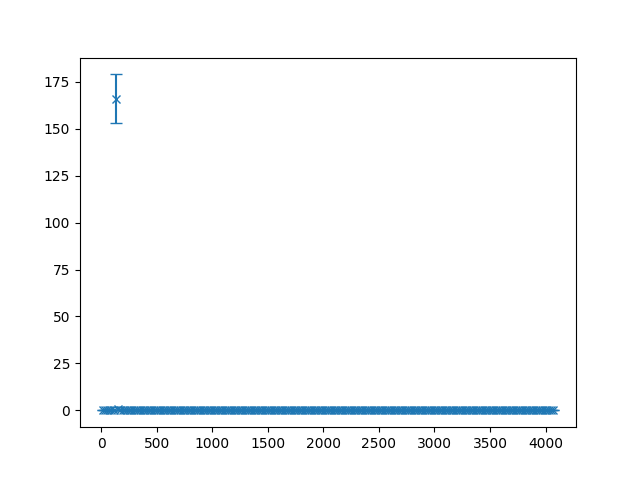

In [183]:
# background time spectrum

time_background = read_data('RawData/spectrum/time_background_3.TKA', cutoff=2).astype(float)
time_background_time = read_data('RawData/spectrum/time_background_3.TKA', cutoff=0)[0]
time_background_channel = np.arange(2, 2 + len(time_background))
time_background_time = np.float64(time_background_time)

time_background_uncertainty = np.sqrt(time_background)


# bin the data to reduce noise
binned_time_background_channel, binned_time_background, binned_error_time_background = bin_data_poisson(
    time_background_channel, time_background, yerr = time_background_uncertainty, bin_width = 20)

# plot the binned data
plt.figure()
plt.errorbar(binned_time_background_channel, binned_time_background, yerr=binned_error_time_background, fmt='x', capsize=4, label='Data')


=== ODR-Fit (Zeit) ===
A    = 431.2029 ± 9.4103
τ    = 2.0618 ± 0.0528  (µs)
C    = 11.7615 ± 1.3685
Reduced χ² = 1.06


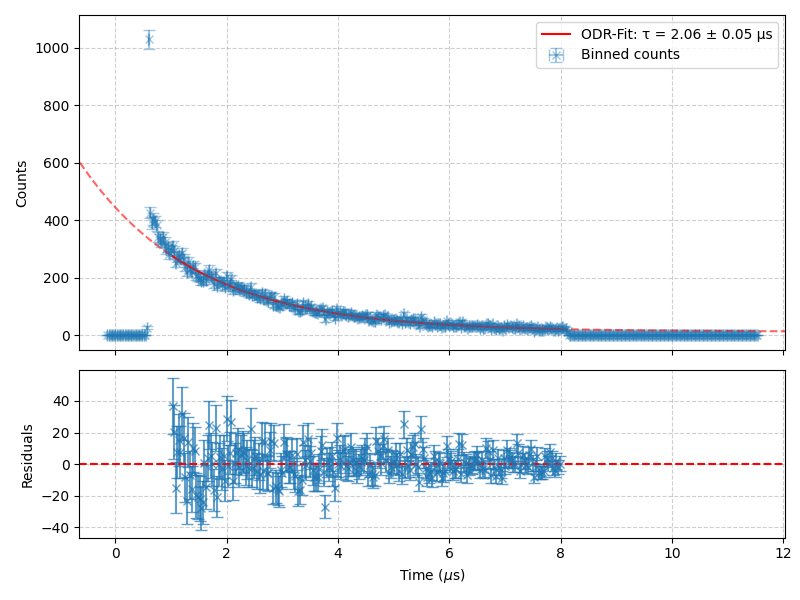

In [226]:
# --------------------------------------------------------------
#  0) Modell: exponentieller Zerfall + Offset
# --------------------------------------------------------------
def odr_exp_decay(B, x):
    """B = [A, tau, C] → A·exp(-x/tau) + C"""
    A, tau, C = B
    return A * np.exp(-x / tau) + C


# --------------------------------------------------------------
#  1) Rohdaten einlesen
# --------------------------------------------------------------
time_spectrum      = read_data('RawData/spectrum/time_signal_5.TKA', cutoff=2).astype(float)
time_spectrum_chan = np.arange(2, 2 + len(time_spectrum))


# --------------------------------------------------------------
#  2) Poisson-Fehler (σy = √N)
# --------------------------------------------------------------
sigma_y = np.sqrt(time_spectrum)


# --------------------------------------------------------------
#  3) Binning (stabilisiert Fit)
# --------------------------------------------------------------
bin_width = 10
b_chan, b_cnt, b_err = bin_data_poisson(
    time_spectrum_chan,
    time_spectrum,
    yerr=sigma_y,
    bin_width=bin_width
)


# --------------------------------------------------------------
#  4) Unsicherheit auf Channel
# --------------------------------------------------------------
# physikalisch sinnvoll: ~0.5–1 Channel
sigma_x = 0 * np.ones_like(b_chan)


# --------------------------------------------------------------
#  6) Channel → Zeit kalibrieren
# --------------------------------------------------------------
t_binned, dt_binned = mu_to_delay_with_error(
    mu=b_chan,
    dmu=sigma_x,
    m=m_odr,
    b=b_odr,
    dm=dm_odr,
    db=db_odr
)


# --------------------------------------------------------------
#  7) Fitbereich definieren (jetzt in ZEIT!)
# --------------------------------------------------------------
mask_time = (
    (t_binned >= 1) &
    (t_binned <= 8) &
    (b_err > 0) &
    np.isfinite(b_cnt)
)

x_fit_time  = t_binned[mask_time]
y_fit_time  = b_cnt[mask_time]
sx_fit_time = dt_binned[mask_time]
sy_fit_time = b_err[mask_time]


# --------------------------------------------------------------
#  8) ODR-Fit in ZEIT
# --------------------------------------------------------------
model = Model(odr_exp_decay)

data_time = RealData(
    x=x_fit_time,
    y=y_fit_time,
    sx=sx_fit_time,
    sy=sy_fit_time
)

# Startwerte: tau jetzt in µs!
beta0 = [145., 2.0, 0.]

odr_time = ODR(data_time, model, beta0=beta0, maxit=10000)
out_time = odr_time.run()

popt_time = out_time.beta
perr_time = out_time.sd_beta

print("\n=== ODR-Fit (Zeit) ===")
print(f"A    = {popt_time[0]:.4f} ± {perr_time[0]:.4f}")
print(f"τ    = {popt_time[1]:.4f} ± {perr_time[1]:.4f}  (µs)")
print(f"C    = {popt_time[2]:.4f} ± {perr_time[2]:.4f}")
print(f"Reduced χ² = {out_time.res_var:.2f}")


# --------------------------------------------------------------
#  9) Fitkurve (für Plot)
# --------------------------------------------------------------
x_curve_time = np.linspace(min(t_binned), max(t_binned), 2000)
y_curve_time = odr_exp_decay(popt_time, x_curve_time)


# --------------------------------------------------------------
# 10) Residuen
# --------------------------------------------------------------
residuals = y_fit_time - odr_exp_decay(popt_time, x_fit_time)


# --------------------------------------------------------------
#  9) Fitkurve (für Plot) + Aufteilung
# --------------------------------------------------------------
x_curve_time = np.linspace(min(t_binned)-1, max(t_binned)+1, 2000)
y_curve_time = odr_exp_decay(popt_time, x_curve_time)

# Fitbereich-Grenzen
x_fit_min = np.min(x_fit_time)
x_fit_max = np.max(x_fit_time)

# Masken für Darstellung
mask_left  = x_curve_time < x_fit_min
mask_mid   = (x_curve_time >= x_fit_min) & (x_curve_time <= x_fit_max)
mask_right = x_curve_time > x_fit_max


# --------------------------------------------------------------
# 11) Plot: Fit + Residuen
# --------------------------------------------------------------
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8,6), sharex=True,
                               gridspec_kw={'height_ratios':[2,1]})

# --- Daten ---
ax0.errorbar(
    t_binned,
    b_cnt,
    xerr=dt_binned,
    yerr=b_err,
    fmt='x',
    capsize=4,
    alpha=0.4,
    label='Binned counts'
)

# --- Fit links (gestrichelt) ---
ax0.plot(
    x_curve_time[mask_left],
    y_curve_time[mask_left],
    'r--',
    alpha=0.6
)

# --- Fitbereich (durchgezogen) ---
ax0.plot(
    x_curve_time[mask_mid],
    y_curve_time[mask_mid],
    'r-',
    lw=1.5,
    label=f'ODR-Fit: τ = {popt_time[1]:.2f} ± {perr_time[1]:.2f} µs'
)

# --- Fit rechts (gestrichelt) ---
ax0.plot(
    x_curve_time[mask_right],
    y_curve_time[mask_right],
    'r--',
    alpha=0.6
)

ax0.set_ylabel('Counts')
ax0.grid(True, ls='--', alpha=0.6)
ax0.legend()


# --- Residuen ---
ax1.errorbar(
    x_fit_time,
    residuals,
    yerr=sy_fit_time,
    fmt='x',
    capsize=4,
    alpha=0.7
)

ax1.axhline(0, color='red', linestyle='--')
ax1.set_xlabel(r'Time ($\mu$s)')
ax1.set_ylabel('Residuals')
ax1.grid(True, ls='--', alpha=0.6)

plt.tight_layout()
plt.xlim(min(t_binned)-0.5, max(t_binned)+0.5)
plt.savefig('Results/time_fit_with_residuals.pdf')
plt.show()

## $\beta$ Spectrum

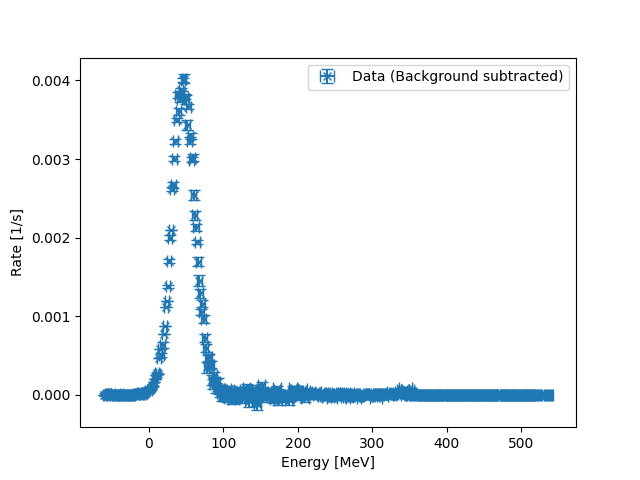

In [257]:
beta_spectrum = read_data('RawData/spectrum/beta_signal_5.TKA', cutoff = 2)
beta_spectrum_channel = np.arange(2, 2 + len(time_spectrum))
#sigma_x_channels = sigma_PES_single_value * np.ones_like(beta_spectrum_channel)

beta_spectrum_time = read_data('RawData/spectrum/beta_signal_5.TKA', cutoff = 0)[0]
beta_spectrum_time = np.float64(beta_spectrum_time)

beta_spectrum = beta_spectrum/beta_spectrum_time
beta_spectrum_uncertainty = uncertainty_rate(beta_spectrum, beta_spectrum_time, dt_spectrometer)


beta_spectrum = beta_spectrum - beta_background/beta_background_time
beta_spectrum_uncertainty = np.sqrt(beta_spectrum_uncertainty**2 + uncertainty_rate(beta_background, beta_background_time, dt_spectrometer)**2)


binned_beta_spectrum_channel, binned_beta_spectrum, binned_error_beta_spectrum = bin_data_poisson(beta_spectrum_channel, beta_spectrum, beta_spectrum_uncertainty, 10)

binned_beta_spectrum_channel_energy = channel_to_energy_with_error(binned_beta_spectrum_channel, m_energycalib, b_energycalib, dm_energycalib, db_energycalib)


plt.figure()
plt.errorbar(binned_beta_spectrum_channel_energy[0], binned_beta_spectrum, xerr = binned_beta_spectrum_channel_energy[1], yerr=binned_error_beta_spectrum, fmt='x', capsize=4, label = 'Data (Background subtracted)')
plt.xlabel('Energy [MeV]')
plt.ylabel('Rate [1/s]')

plt.legend()

#### Fermi Kurie

E_max = 98.84 ± 38.31 MeV


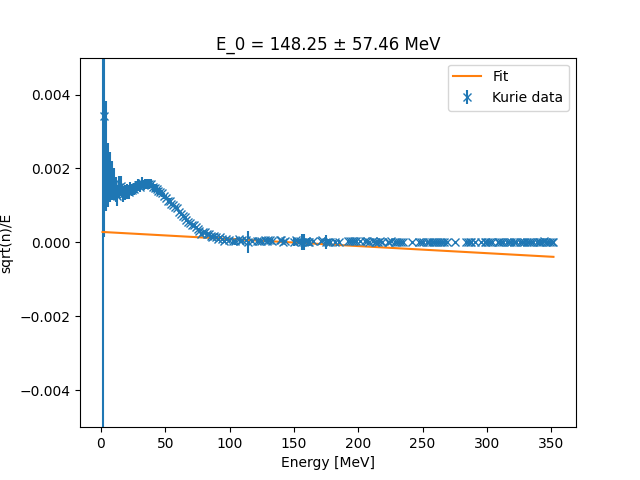

In [253]:
E = binned_beta_spectrum_channel_energy[0]
sigma_E = binned_beta_spectrum_channel_energy[1]

rate = binned_beta_spectrum
sigma_n = binned_error_beta_spectrum

mask = (rate > 0) & (E > 0)

E = E[mask]
sigma_E = sigma_E[mask]
rate = rate[mask]
sigma_n = sigma_n[mask]

y = np.sqrt(rate) / E
sigma_y = np.sqrt(
    (sigma_n / (2 * np.sqrt(rate) * E))**2 +
    ((np.sqrt(rate) / E**2) * sigma_E)**2
)

fit_mask = (E > 90) & (E < 130)


popt, pcov = curve_fit(
    linear,
    E[fit_mask],
    y[fit_mask],
    sigma=sigma_y[fit_mask],
    absolute_sigma=True
)

m, b = popt
dm, db = np.sqrt(np.diag(pcov))

E_0 = -b / m
dE_0 = np.sqrt(
    (db / m)**2 +
    (b * dm / m**2)**2
)

plt.figure()
plt.errorbar(E, y, yerr=sigma_y, fmt='x', label='Kurie data')

# Fitlinie
E_fit = np.linspace(min(E), max(E), 500)
plt.plot(E_fit, linear(E_fit, *popt), label='Fit')

plt.xlabel('Energy [MeV]')
plt.ylabel('sqrt(n)/E')
plt.legend()
#plt.xlim(10)
plt.ylim(-0.005, 0.005)
    
plt.title(f'E_0 = {E_0:.2f} ± {dE_0:.2f} MeV')
print(f'E_max = {2/3*E_0:.2f} ± {2/3*dE_0:.2f} MeV')


=== ODR-Fit (Fermi-Edge, kalibrierte Energie) ===
A      =  0.00 ±  0.00
E0     =  62.554 ± 1.402 MeV
ΔE     =  7.779 ± 0.417 MeV
Reduced χ² = 0.004450684064666763
Muon mass ≈ 125.108 ± 2.805 MeV


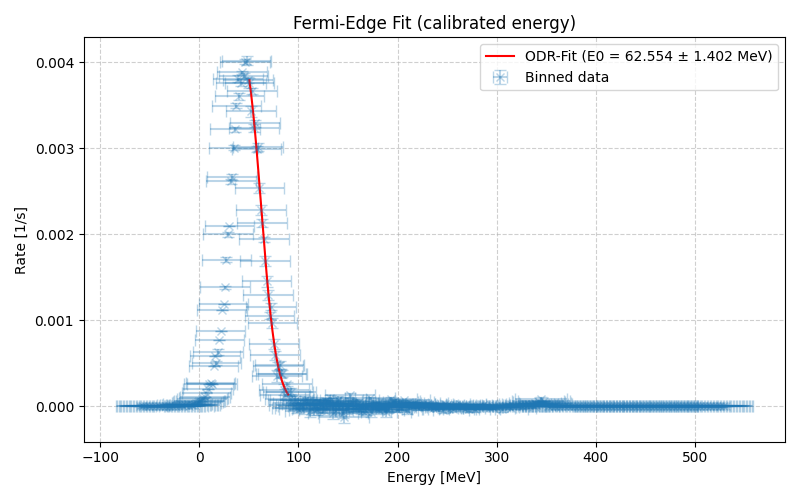

In [273]:
# --------------------------------------------------------------
# 1) Beta-Spektrum bereits vorbereitet und gebinnt
# --------------------------------------------------------------
binned_beta_spectrum_channel_energy = channel_to_energy_with_error(
    binned_beta_spectrum_channel, 
    m_energycalib, b_energycalib, 
    dm_energycalib, db_energycalib, dchannel = sigma_PES_single_value*np.ones_like(binned_beta_spectrum_channel))
E_binned = binned_beta_spectrum_channel_energy[0]  # gemittelte Energie
sigma_E  = binned_beta_spectrum_channel_energy[1]  # x-Unsicherheit in MeV

# Edge-Bereich in Energie
edge_mask = (E_binned > 50) & (E_binned < 90) & (binned_beta_spectrum > 0)  # z.B. 1.5-2.0 MeV, anpassen

E_edge = E_binned[edge_mask]
N_edge = binned_beta_spectrum[edge_mask]
err_y   = binned_error_beta_spectrum[edge_mask]
sigma_x = sigma_E[edge_mask]

# --------------------------------------------------------------
# 2) Startwerte für ODR
# --------------------------------------------------------------
A0      = N_edge.max()
E0_0    = E_edge[np.argmax(N_edge)]
deltaE0 = 10  # in MeV, initial guess
p0 = [A0, E0_0, deltaE0]

# --------------------------------------------------------------
# 3) ODR-Modell (Fermi-Edge)
# --------------------------------------------------------------
def odr_fermi_edge(B, x):
    A, E0, deltaE = B
    return A / (1.0 + np.exp((x - E0) / deltaE))

model = Model(odr_fermi_edge)

# --------------------------------------------------------------
# 4) RealData inkl. x- und y-Fehler
# --------------------------------------------------------------
data = RealData(x=E_edge, y=N_edge, sx=sigma_x, sy=err_y)

# --------------------------------------------------------------
# 5) ODR-Fit
# --------------------------------------------------------------
odr_fit = ODR(data, model, beta0=p0, maxit=10000)
out     = odr_fit.run()

# --------------------------------------------------------------
# 6) Ergebnisse
# --------------------------------------------------------------
params_odr = out.beta
perr_odr   = out.sd_beta
A_fit, E0_fit, deltaE_fit = params_odr
A_err, E0_err, deltaE_err = perr_odr

print("\n=== ODR-Fit (Fermi-Edge, kalibrierte Energie) ===")
print(f"A      = {A_fit: .2f} ± {A_err: .2f}")
print(f"E0     = {E0_fit: .3f} ± {E0_err:.3f} MeV")
print(f"ΔE     = {deltaE_fit: .3f} ± {deltaE_err:.3f} MeV")
print(f"Reduced χ² = {out.res_var}")

# Optional: Muon-Masse
muon_mass     = 2.0 * E0_fit
muon_mass_err = 2.0 * E0_err
print(f"Muon mass ≈ {muon_mass:.3f} ± {muon_mass_err:.3f} MeV")

# --------------------------------------------------------------
# 7) Plot
# --------------------------------------------------------------
E_curve = np.linspace(E_edge.min(), E_edge.max(), 500)
N_curve = odr_fermi_edge(params_odr, E_curve)

plt.figure(figsize=(8,5))
plt.errorbar(E_binned,
             binned_beta_spectrum, 
             xerr = sigma_E,
             yerr=binned_error_beta_spectrum,
             fmt='x', capsize=4, label='Binned data', alpha=0.3)
plt.plot(E_curve, N_curve, 'r-', lw=1.5,
         label=f'ODR-Fit (E0 = {E0_fit:.3f} ± {E0_err:.3f} MeV)')
plt.xlabel('Energy [MeV]')
plt.ylabel('Rate [1/s]')
plt.title('Fermi-Edge Fit (calibrated energy)')
plt.grid(True, ls='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()